In [1]:
# you will be prompted with a window asking to grant permissions
from google.colab import drive
drive.mount("/content/drive")

!mkdir -p /content/computer_vision
!find "/content/drive/Shareddrives/Computer Vision/output/" -mindepth 1 -maxdepth 1 -exec cp -r -t /content/computer_vision/ {} +


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install diffusers

#### model

In [3]:
import torch
import torch.nn.functional as F
from diffusers import UNet2DModel, DDPMScheduler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm # 進度條 (可選，需 pip install tqdm)

device = "cuda" if torch.cuda.is_available() else "cpu"
output_dir = "/content/drive/Shareddrives/Computer Vision/models"

model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256), # 簡化一點以便跑得快
    down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
    num_class_embeds=10, # 支援 10 個類別
).to(device)

# model = UNet2DModel.from_pretrained(output_dir).to(device)
# scheduler = DDPMScheduler.from_pretrained(output_dir)


scheduler = DDPMScheduler(num_train_timesteps=1000)

# 4. 定義優化器 (Optimizer) - 這是真的訓練所必須的
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

num_epochs = 20 # 示範跑 3 個 Epoch

print(f"開始訓練，使用裝置: {device}")

開始訓練，使用裝置: cuda


### data loader

In [4]:
from torchvision import datasets, transforms # 引入 torchvision 來處理圖片

dataset_path = "/content/computer_vision/train" # 指向你的資料集根目錄 (包含 0000, 0001... 的那個資料夾)
image_size = 32
batch_size = 128      # 根據你的顯卡記憶體調整 (16, 32, 64...)

# ==========================================
# 2. 資料載入 (Data Loading) - 針對你的資料夾結構
# ==========================================
# 定義圖片預處理
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)), # 強制縮放到模型輸入大小
    transforms.ToTensor(),                       # 轉成 Tensor (數值變 0~1)
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # 正規化到 -1 ~ 1 (這是 DDPM 的標準範圍)
])

# 使用 ImageFolder 自動讀取
# 它會自動把 '0000' 資料夾當作 class 0, '0001' 當作 class 1... 依此類推
try:
    dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
    num_classes = len(dataset.classes) # 自動偵測有多少個類別資料夾
    print(f"成功讀取資料集！")
    print(f"總圖片數: {len(dataset)}")
    print(f"偵測到的類別數: {num_classes} (類別對應: {dataset.class_to_idx})")
except Exception as e:
    print(f"讀取資料失敗，請檢查路徑。錯誤: {e}")
    exit()

train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

成功讀取資料集！
總圖片數: 10331
偵測到的類別數: 10 (類別對應: {'0000': 0, '0001': 1, '0002': 2, '0003': 3, '0004': 4, '0005': 5, '0006': 6, '0007': 7, '0008': 8, '0009': 9})


### training

In [5]:
def inference_demo(model):
  # ==========================================
  # 3. 條件生成過程 (Conditional Sampling)
  # ==========================================
  # 目標：生成 4 張屬於「類別 3」的圖片
  target_class_idx = 5
  inference_batch_size = 4

  print(f"開始生成類別 {target_class_idx} 的圖片...")

  # 1. 隨機生成初始噪音 (Pure Noise)
  image = torch.randn(inference_batch_size, 3, 32, 32).to(device)

  # 2. 準備條件標籤 (全部都是 3)
  class_labels = torch.tensor([target_class_idx] * inference_batch_size).to(device)

  # 3. 逐步去噪 (Denoising Loop)
  for t in scheduler.timesteps:
      with torch.no_grad():
          # 預測噪音
          # 在推論時，我們持續傳入 class_labels，引導模型往該類別生成
          model_output = model(
              image,
              t,
              class_labels=class_labels
          ).sample

      # 根據預測的噪音移除一部分，更新圖片
      image = scheduler.step(model_output, t, image).prev_sample

  print(f"生成完成！輸出圖片形狀: {image.shape}")
  import matplotlib.pyplot as plt
  print("正在處理並顯示圖片...")

  # 步驟 A: 後處理 Tensor
  # 1. 將 Tensor 移回 CPU
  output_images = image.cpu()

  # 2. 數值範圍調整
  # 擴散模型的輸出通常假設在 [-1, 1] 之間。
  # 我們將其映射回 [0, 1] 以便 matplotlib 顯示。
  # 公式: (x / 2) + 0.5
  output_images = (output_images / 2 + 0.5)

  # 3. 確保數值不超出 [0, 1] 範圍 (Clamp)
  output_images = output_images.clamp(0, 1)

  # 4. 轉換維度順序
  # PyTorch 是 [Batch, Channel, Height, Width] -> [B, C, H, W]
  # Matplotlib 需要 [Batch, Height, Width, Channel] -> [B, H, W, C]
  output_images_np = output_images.permute(0, 2, 3, 1).numpy()


  # 步驟 B: 使用 Matplotlib 繪圖
  # 建立一個 1 row, 4 columns 的子圖畫布
  fig, axes = plt.subplots(1, inference_batch_size, figsize=(12, 3))

  # 如果只有產生一張圖，axes 可能不是列表，統一處理一下
  if inference_batch_size == 1:
    axes = [axes]

  for i in range(inference_batch_size):
    ax = axes[i]
    # 取出第 i 張圖的數據
    img_data = output_images_np[i]

    # 顯示圖片
    ax.imshow(img_data)
    ax.set_title(f"Class: {target_class_idx}")
    # 關閉座標軸顯示
    ax.axis('off')

  plt.tight_layout()
  print("顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):")
  plt.show()

In [7]:
epochs_completed = 20


Epoch 1/100: 100%|██████████| 81/81 [00:09<00:00,  8.91it/s, loss=0.0184]


Epoch 190 完成，平均 Loss: 0.0234
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


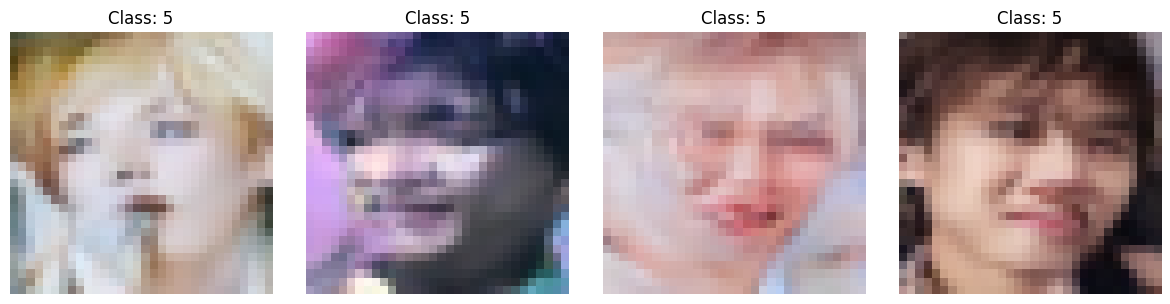

Epoch 2/100: 100%|██████████| 81/81 [00:09<00:00,  8.87it/s, loss=0.0156]


Epoch 191 完成，平均 Loss: 0.0240
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


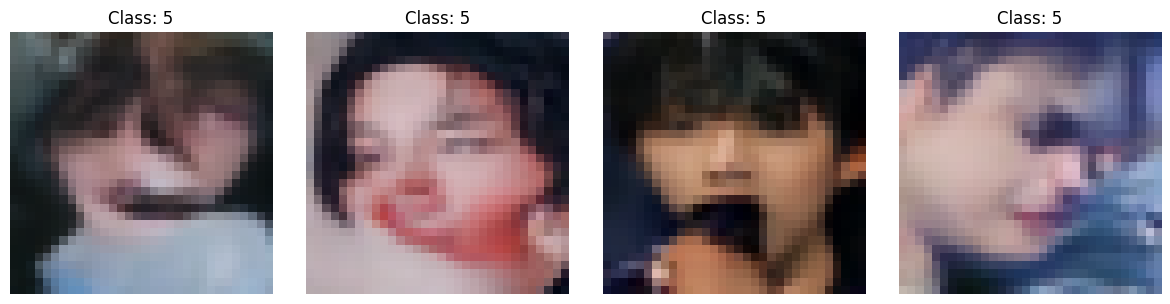

Epoch 3/100: 100%|██████████| 81/81 [00:09<00:00,  8.90it/s, loss=0.0265]


Epoch 192 完成，平均 Loss: 0.0223
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


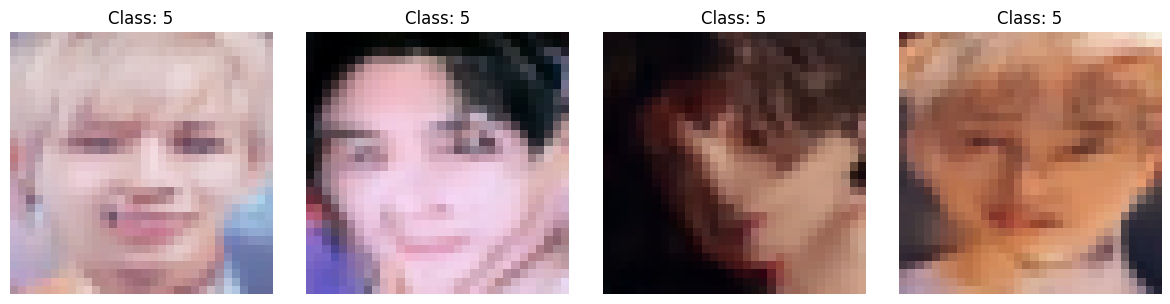

Epoch 4/100: 100%|██████████| 81/81 [00:09<00:00,  8.84it/s, loss=0.0133]


Epoch 193 完成，平均 Loss: 0.0235
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


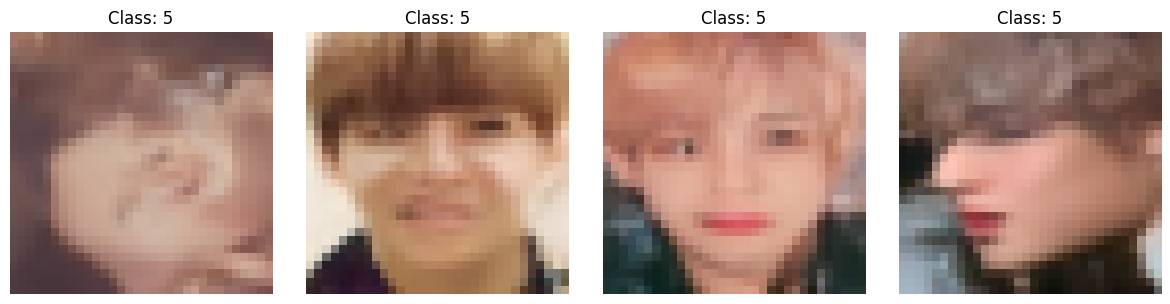

Epoch 5/100: 100%|██████████| 81/81 [00:09<00:00,  8.88it/s, loss=0.0236]


Epoch 194 完成，平均 Loss: 0.0227
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


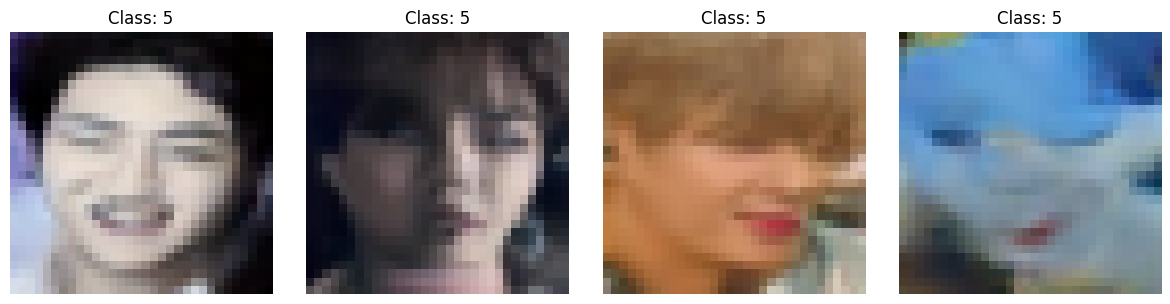

Epoch 6/100: 100%|██████████| 81/81 [00:09<00:00,  8.92it/s, loss=0.0184]


Epoch 195 完成，平均 Loss: 0.0228
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


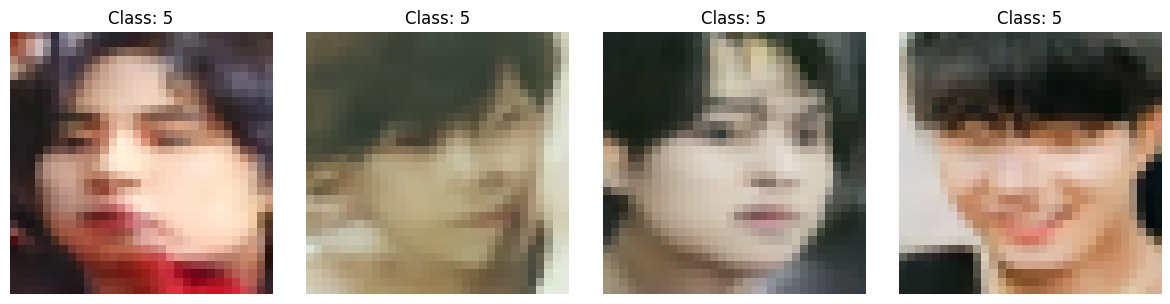

Epoch 7/100: 100%|██████████| 81/81 [00:09<00:00,  8.78it/s, loss=0.0211]


Epoch 196 完成，平均 Loss: 0.0234
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


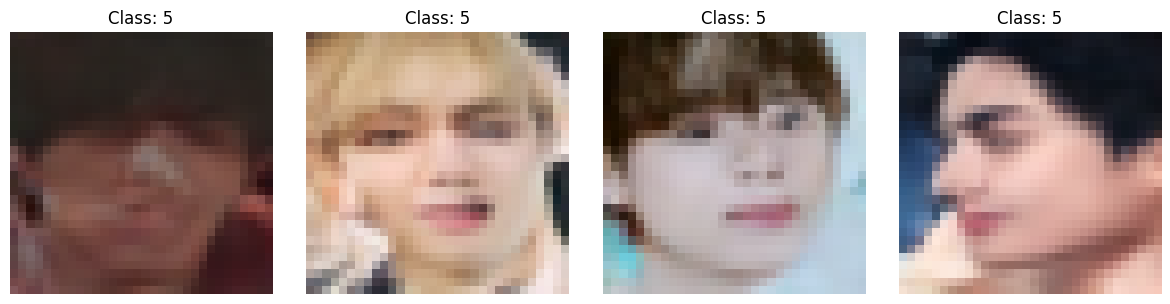

Epoch 8/100: 100%|██████████| 81/81 [00:09<00:00,  8.73it/s, loss=0.0287]


Epoch 197 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


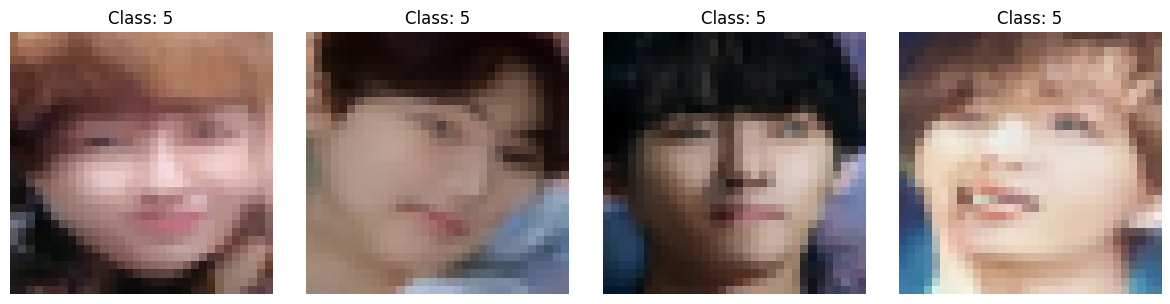

Epoch 9/100: 100%|██████████| 81/81 [00:09<00:00,  8.80it/s, loss=0.024]


Epoch 198 完成，平均 Loss: 0.0238
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


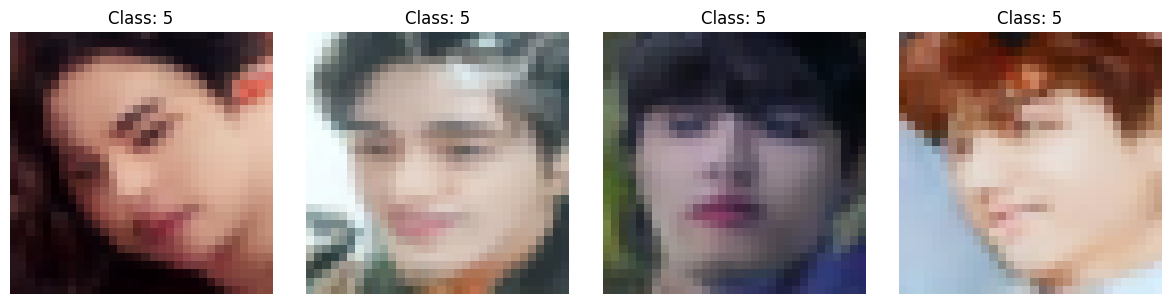

Epoch 10/100: 100%|██████████| 81/81 [00:09<00:00,  8.80it/s, loss=0.0208]


Epoch 199 完成，平均 Loss: 0.0228
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


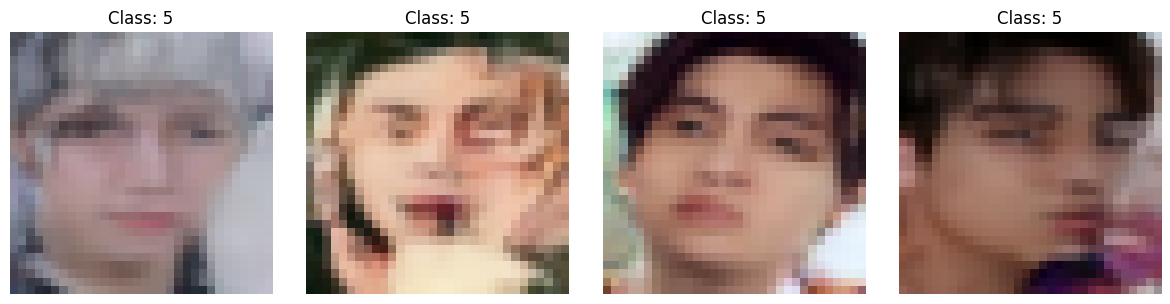

Epoch 11/100: 100%|██████████| 81/81 [00:09<00:00,  8.79it/s, loss=0.019]


Epoch 200 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


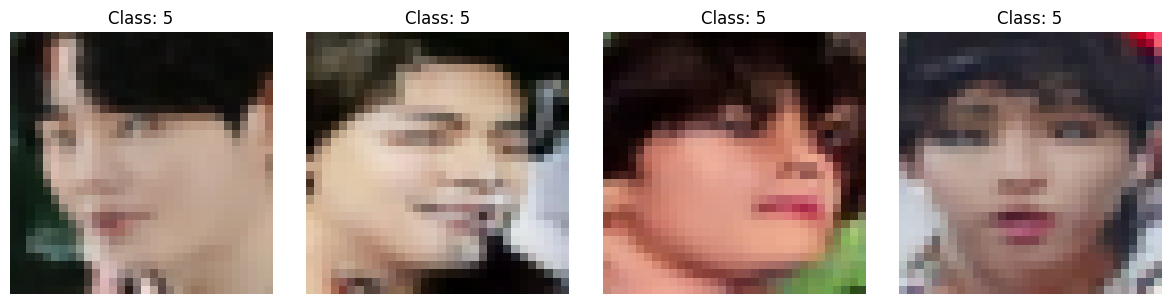

Epoch 12/100: 100%|██████████| 81/81 [00:09<00:00,  8.79it/s, loss=0.0249]


Epoch 201 完成，平均 Loss: 0.0238
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


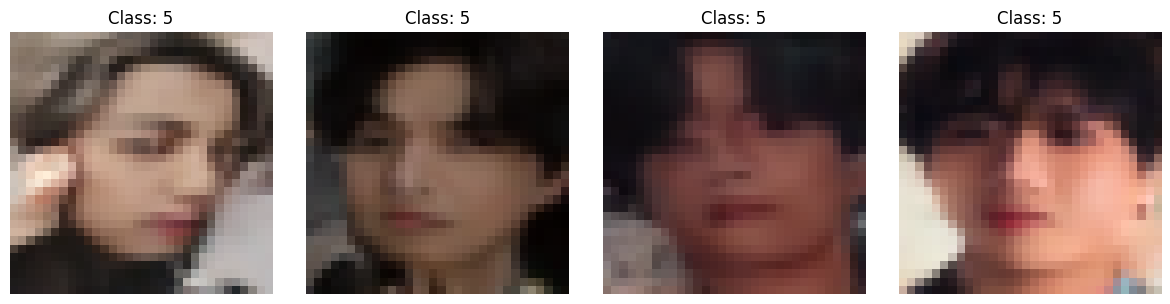

💡 觸發 Learning Rate 衰減：從 1e-4 降為 1e-5 on 202


Epoch 13/100: 100%|██████████| 81/81 [00:09<00:00,  8.75it/s, loss=0.0149]


Epoch 202 完成，平均 Loss: 0.0235
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


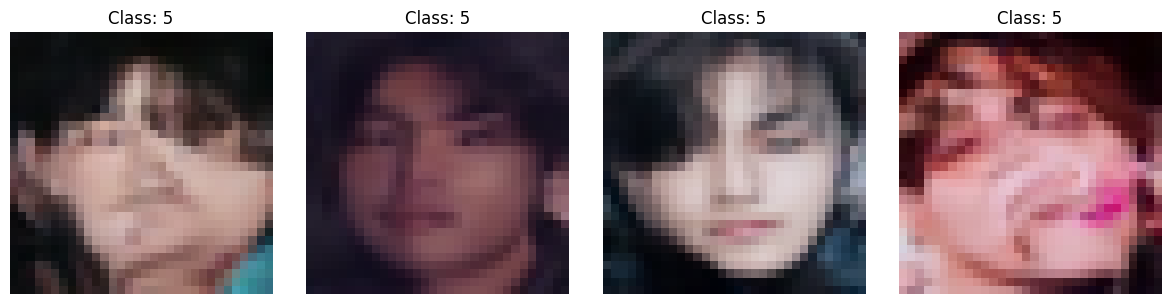

Epoch 14/100: 100%|██████████| 81/81 [00:09<00:00,  8.78it/s, loss=0.0257]


Epoch 203 完成，平均 Loss: 0.0235
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


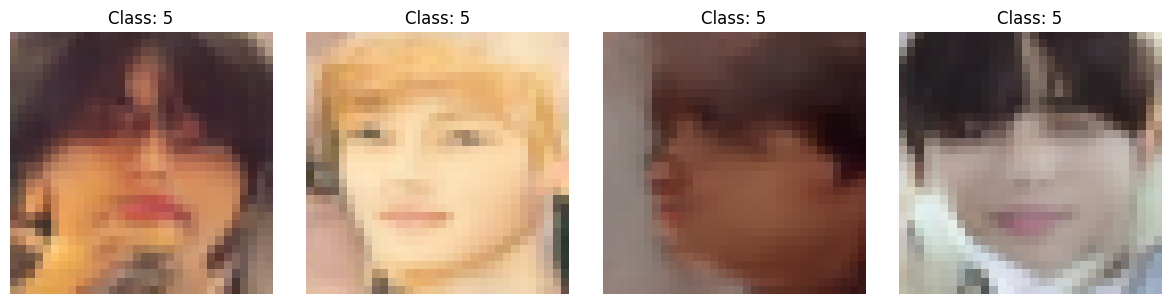

Epoch 15/100: 100%|██████████| 81/81 [00:09<00:00,  8.77it/s, loss=0.0262]


Epoch 204 完成，平均 Loss: 0.0238
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


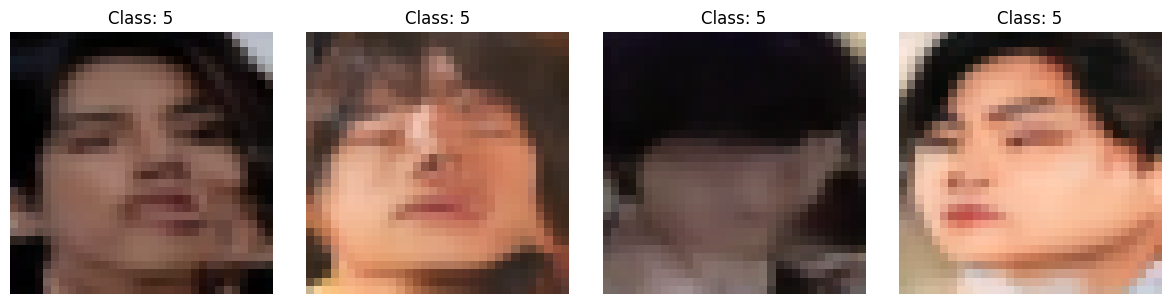

Epoch 16/100: 100%|██████████| 81/81 [00:09<00:00,  8.77it/s, loss=0.0178]


Epoch 205 完成，平均 Loss: 0.0238
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


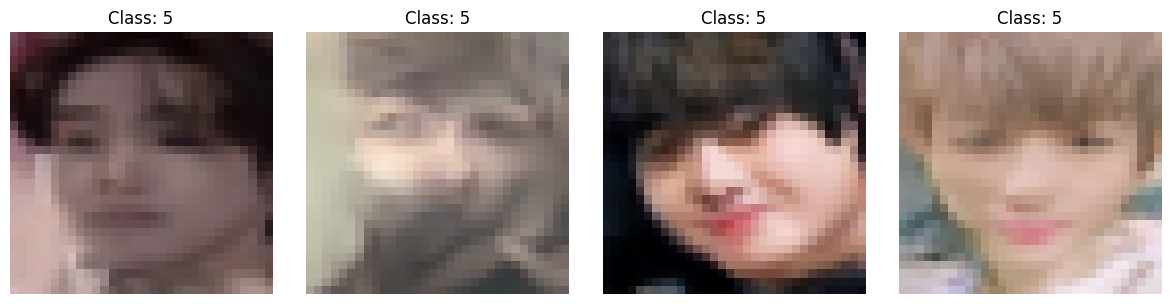

Epoch 17/100: 100%|██████████| 81/81 [00:09<00:00,  8.72it/s, loss=0.0228]


Epoch 206 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


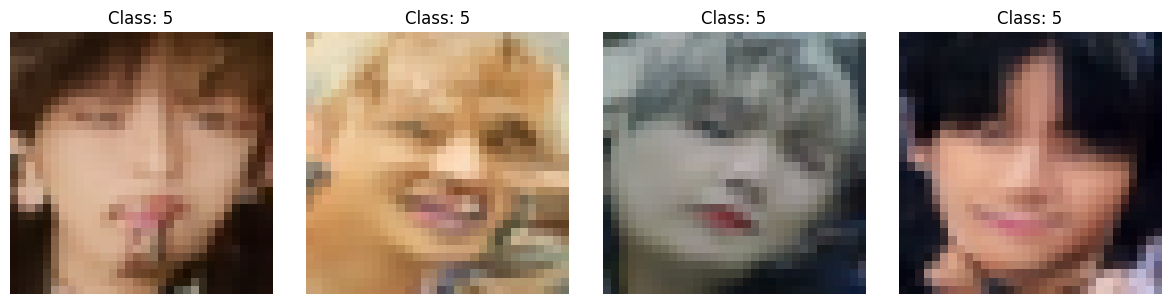

Epoch 18/100: 100%|██████████| 81/81 [00:09<00:00,  8.86it/s, loss=0.02]


Epoch 207 完成，平均 Loss: 0.0228
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


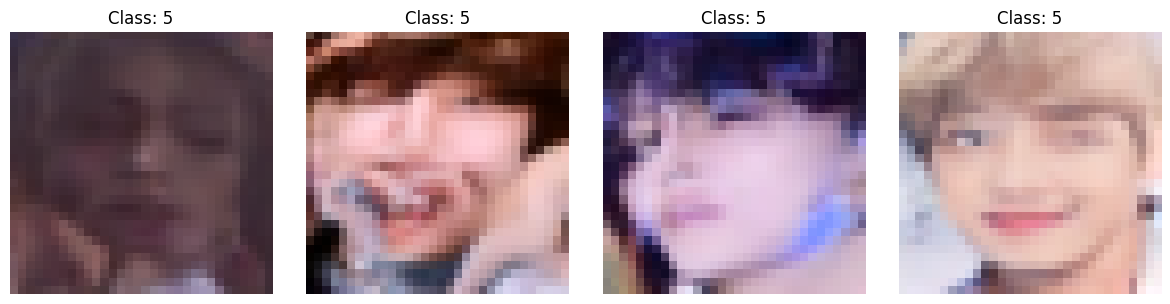

Epoch 19/100: 100%|██████████| 81/81 [00:09<00:00,  8.78it/s, loss=0.0202]


Epoch 208 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


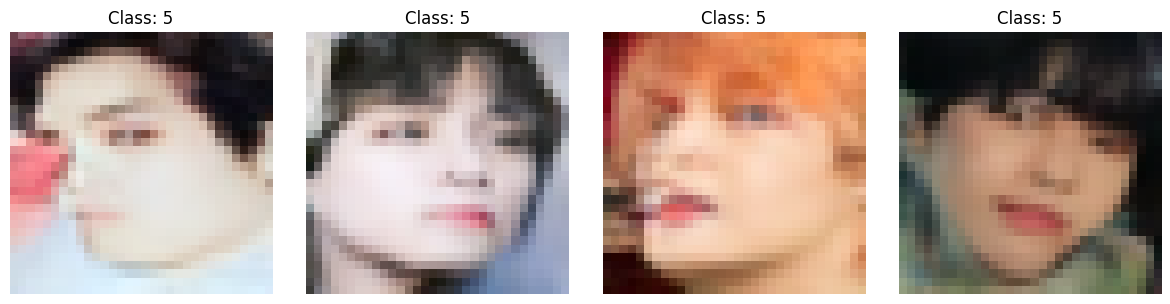

Epoch 20/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.0205]


Epoch 209 完成，平均 Loss: 0.0236
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


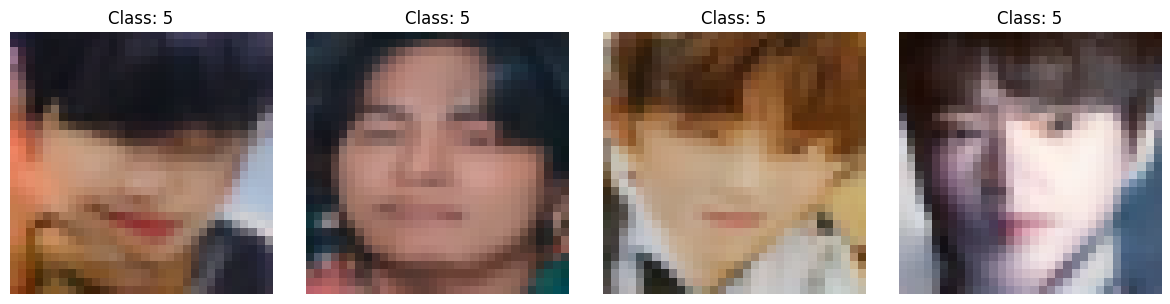

Epoch 21/100: 100%|██████████| 81/81 [00:09<00:00,  8.87it/s, loss=0.0213]


Epoch 210 完成，平均 Loss: 0.0231
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


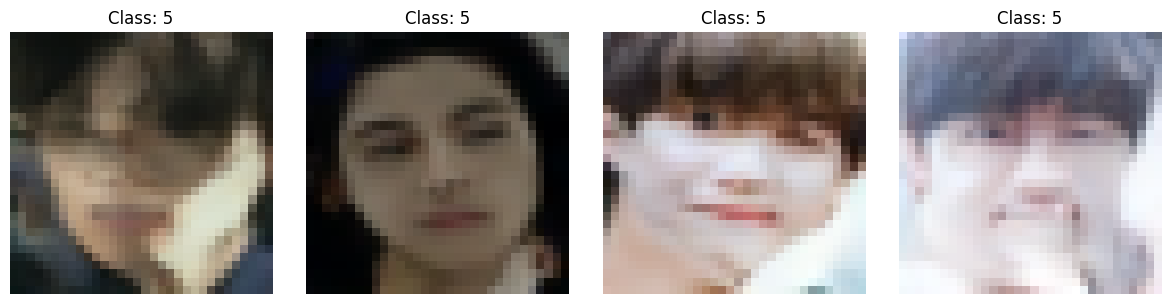

Epoch 22/100: 100%|██████████| 81/81 [00:09<00:00,  8.88it/s, loss=0.021]


Epoch 211 完成，平均 Loss: 0.0234
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


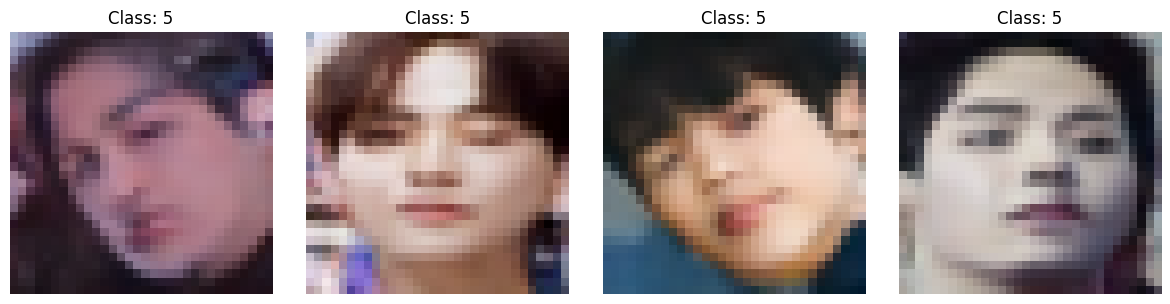

Epoch 23/100: 100%|██████████| 81/81 [00:09<00:00,  8.91it/s, loss=0.0162]


Epoch 212 完成，平均 Loss: 0.0228
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


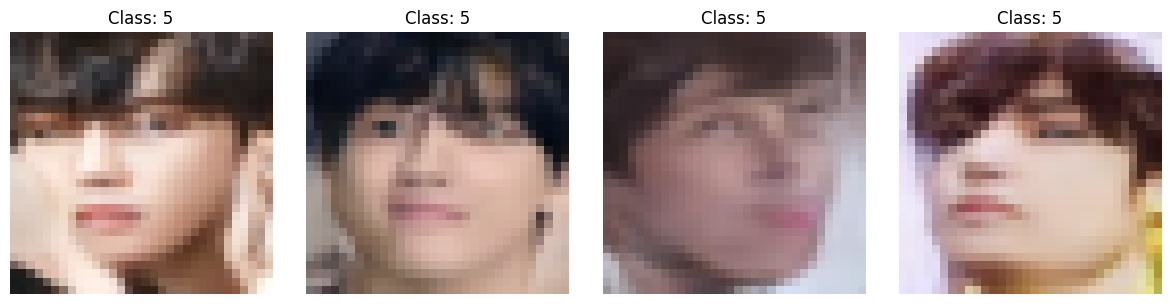

Epoch 24/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.022]


Epoch 213 完成，平均 Loss: 0.0227
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


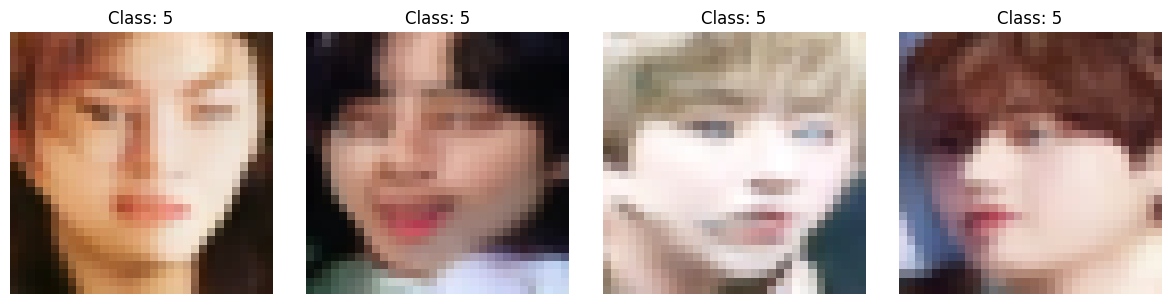

Epoch 25/100: 100%|██████████| 81/81 [00:09<00:00,  8.88it/s, loss=0.0214]


Epoch 214 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


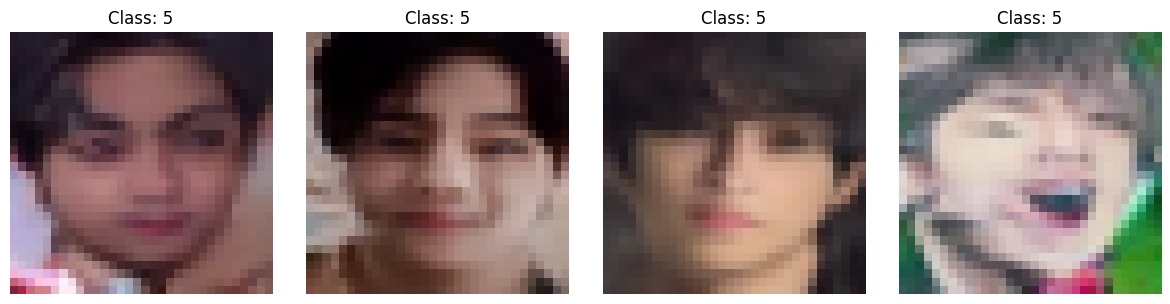

Epoch 26/100: 100%|██████████| 81/81 [00:09<00:00,  8.89it/s, loss=0.0344]


Epoch 215 完成，平均 Loss: 0.0240
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


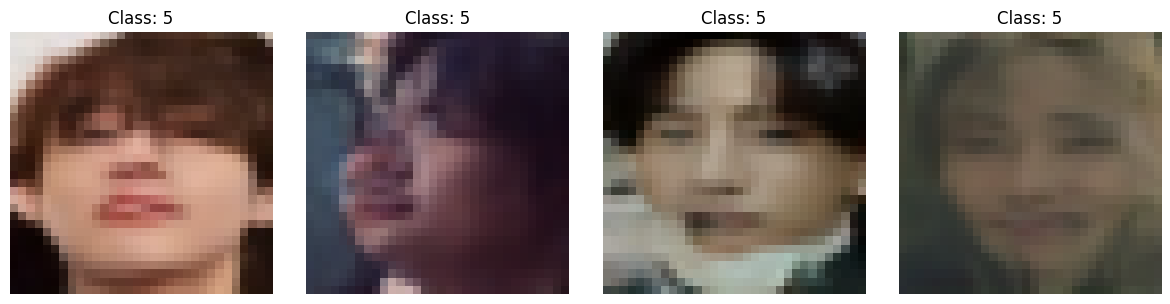

Epoch 27/100: 100%|██████████| 81/81 [00:09<00:00,  8.87it/s, loss=0.0135]


Epoch 216 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


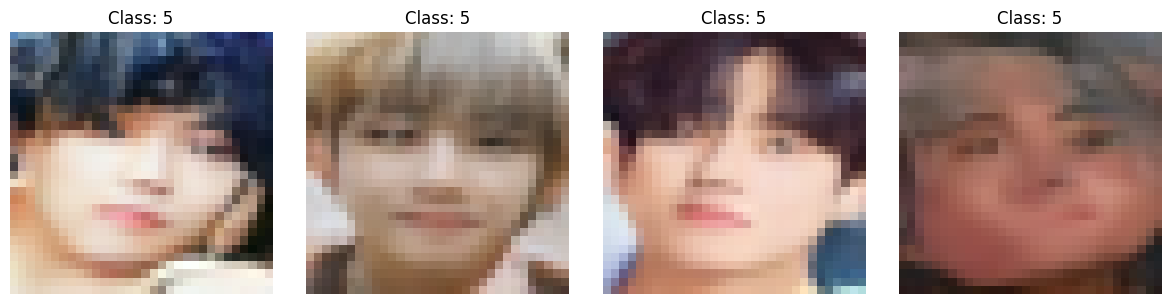

Epoch 28/100: 100%|██████████| 81/81 [00:09<00:00,  8.84it/s, loss=0.0245]


Epoch 217 完成，平均 Loss: 0.0229
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


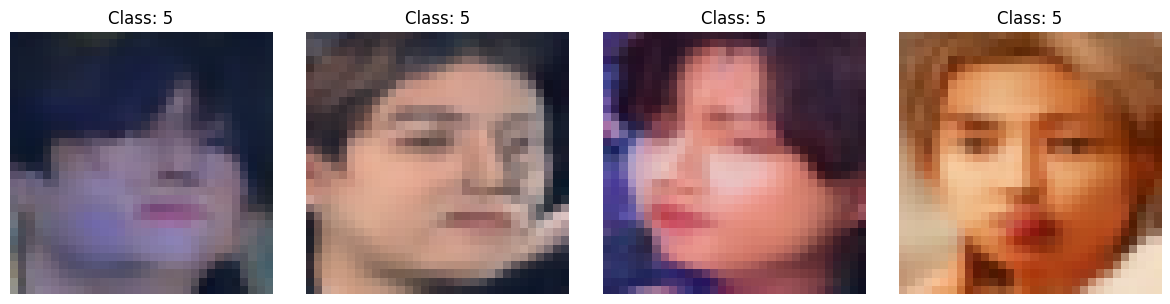

Epoch 29/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.0221]


Epoch 218 完成，平均 Loss: 0.0227
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


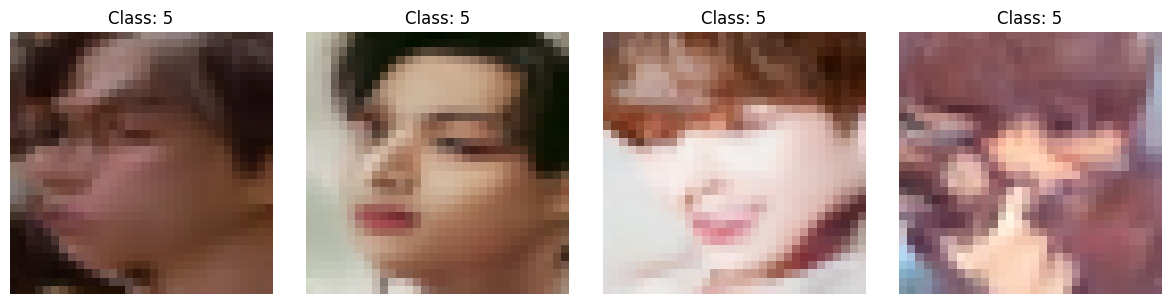

Epoch 30/100: 100%|██████████| 81/81 [00:09<00:00,  8.84it/s, loss=0.0237]


Epoch 219 完成，平均 Loss: 0.0238
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


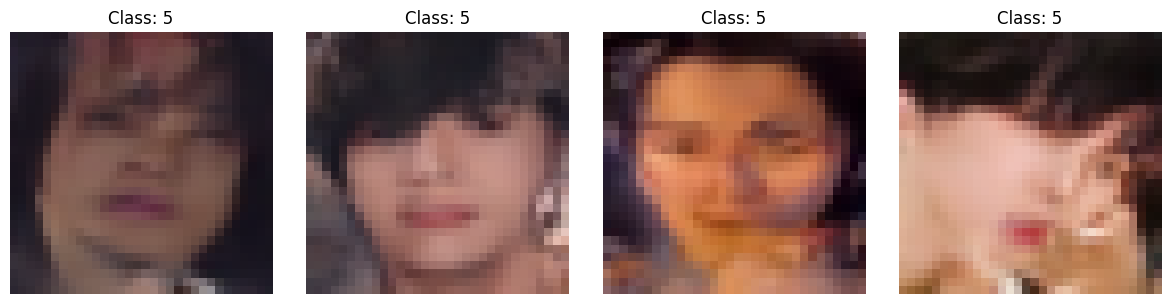

Epoch 31/100: 100%|██████████| 81/81 [00:09<00:00,  8.83it/s, loss=0.0208]


Epoch 220 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


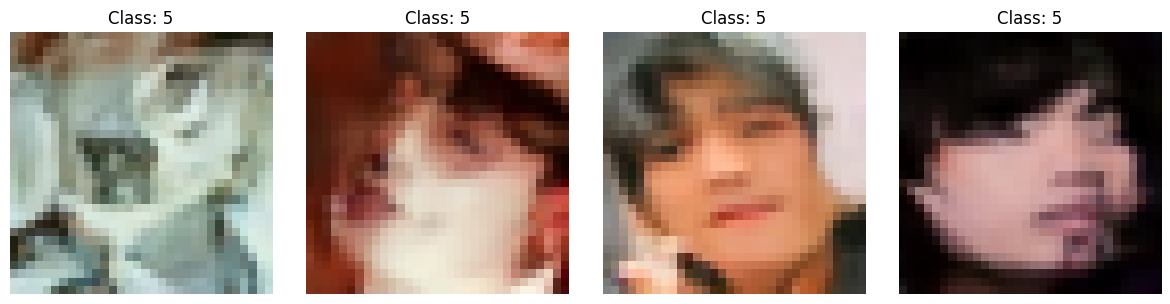

Epoch 32/100: 100%|██████████| 81/81 [00:09<00:00,  8.90it/s, loss=0.0227]


Epoch 221 完成，平均 Loss: 0.0226
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


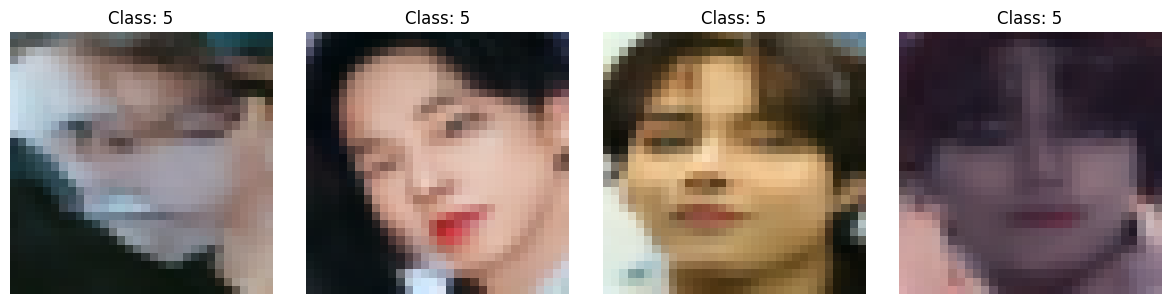

Epoch 33/100: 100%|██████████| 81/81 [00:09<00:00,  8.89it/s, loss=0.0267]


Epoch 222 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


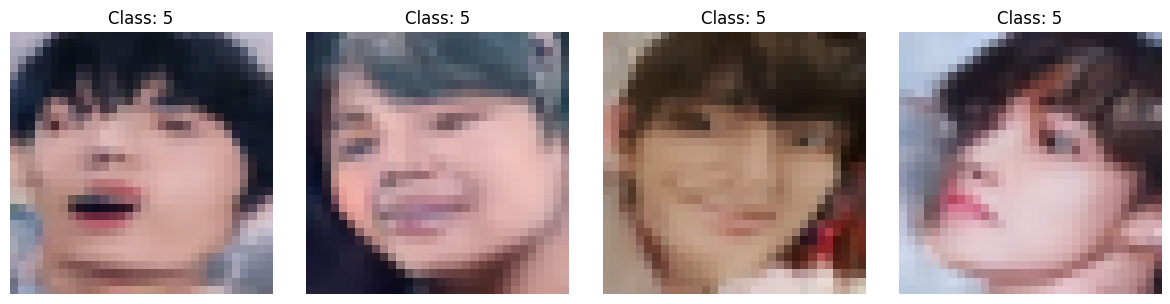

Epoch 34/100: 100%|██████████| 81/81 [00:09<00:00,  8.88it/s, loss=0.0227]


Epoch 223 完成，平均 Loss: 0.0228
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


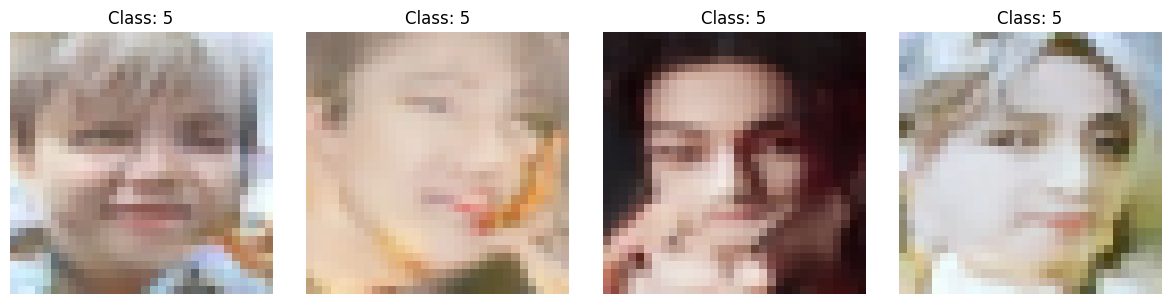

Epoch 35/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.0262]


Epoch 224 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


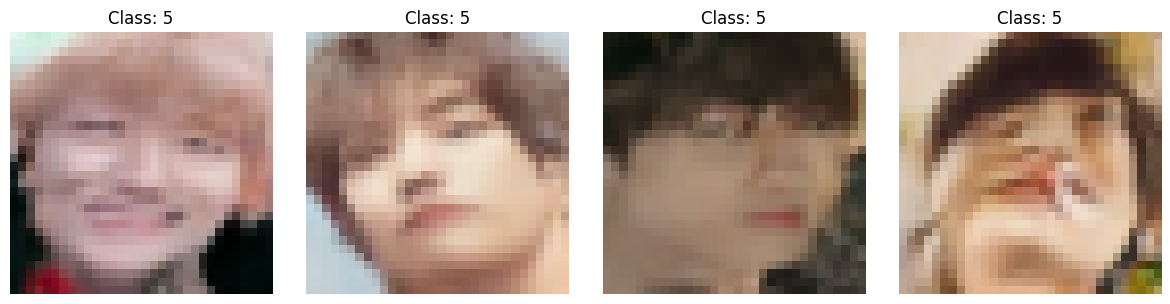

Epoch 36/100: 100%|██████████| 81/81 [00:09<00:00,  8.90it/s, loss=0.0201]


Epoch 225 完成，平均 Loss: 0.0230
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


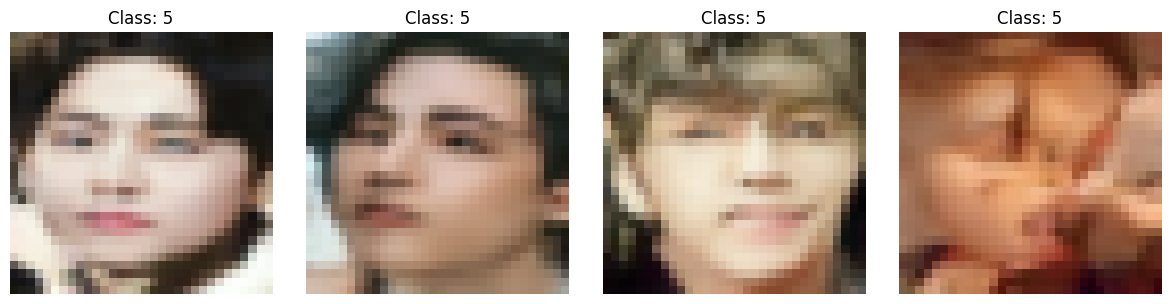

Epoch 37/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.0153]


Epoch 226 完成，平均 Loss: 0.0231
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


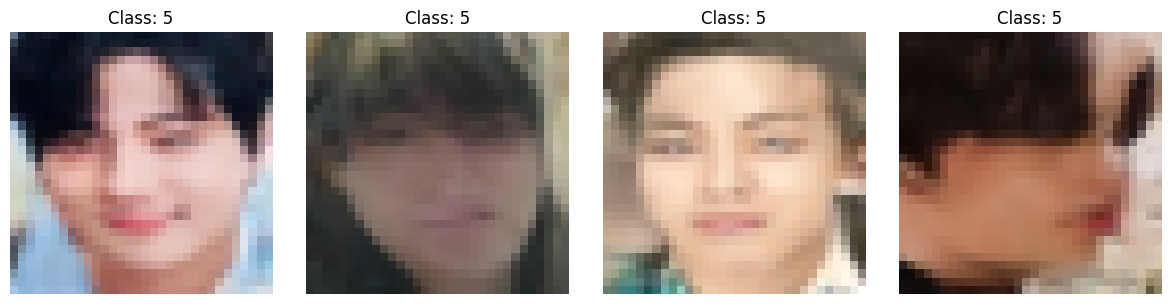

Epoch 38/100: 100%|██████████| 81/81 [00:09<00:00,  8.92it/s, loss=0.0326]


Epoch 227 完成，平均 Loss: 0.0229
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


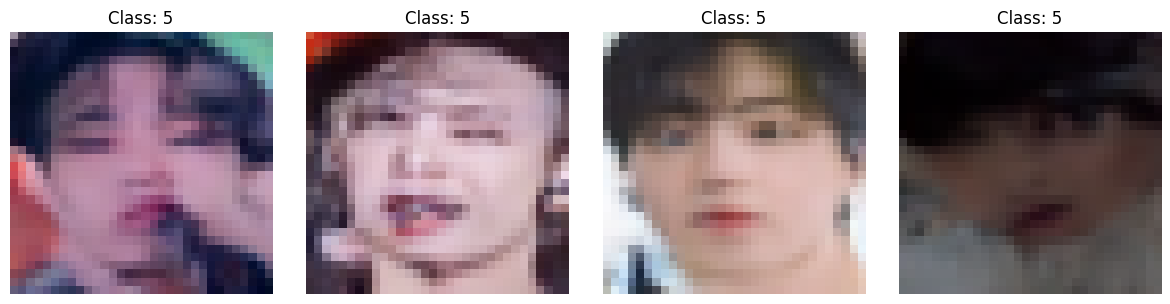

Epoch 39/100: 100%|██████████| 81/81 [00:09<00:00,  8.90it/s, loss=0.0266]


Epoch 228 完成，平均 Loss: 0.0225
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


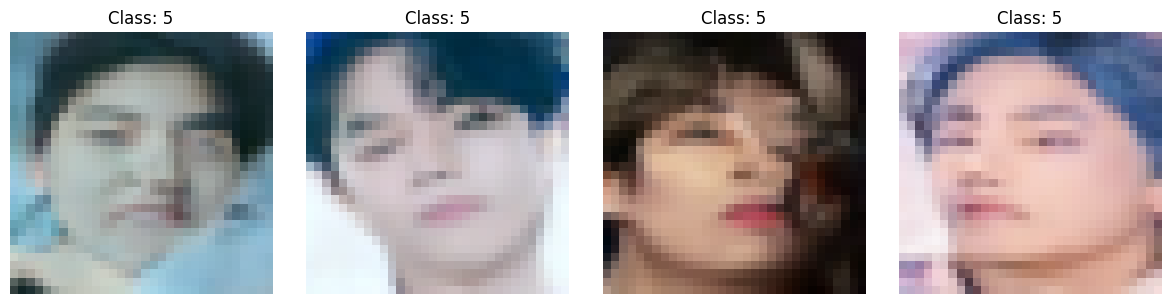

Epoch 40/100: 100%|██████████| 81/81 [00:09<00:00,  8.88it/s, loss=0.025]


Epoch 229 完成，平均 Loss: 0.0239
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


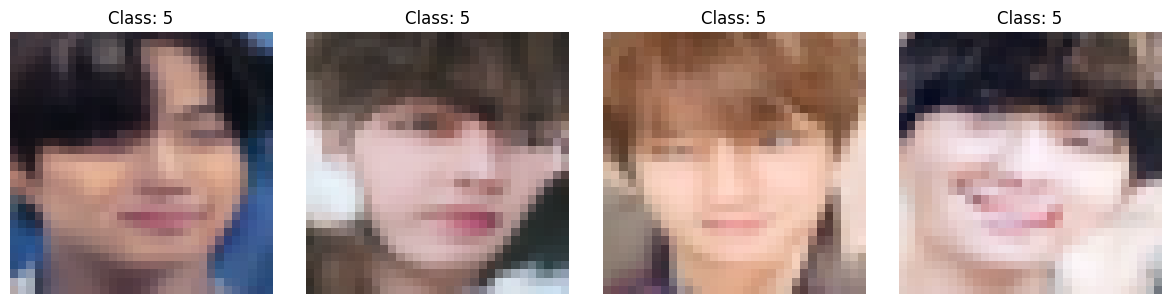

Epoch 41/100: 100%|██████████| 81/81 [00:09<00:00,  8.84it/s, loss=0.0315]


Epoch 230 完成，平均 Loss: 0.0236
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


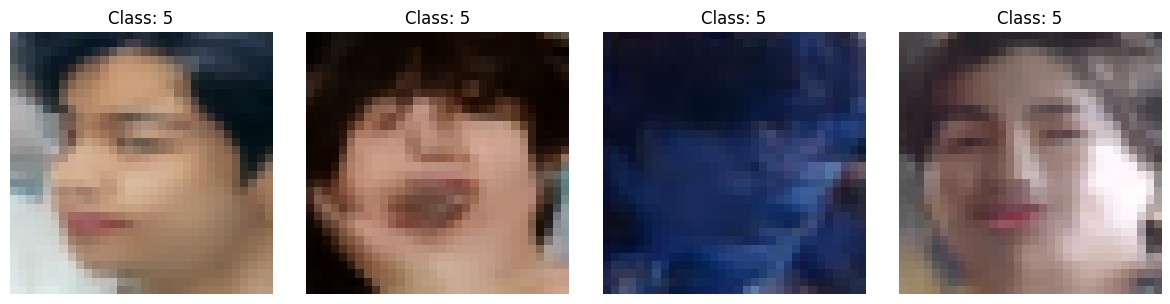

Epoch 42/100: 100%|██████████| 81/81 [00:09<00:00,  8.82it/s, loss=0.0315]


Epoch 231 完成，平均 Loss: 0.0226
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


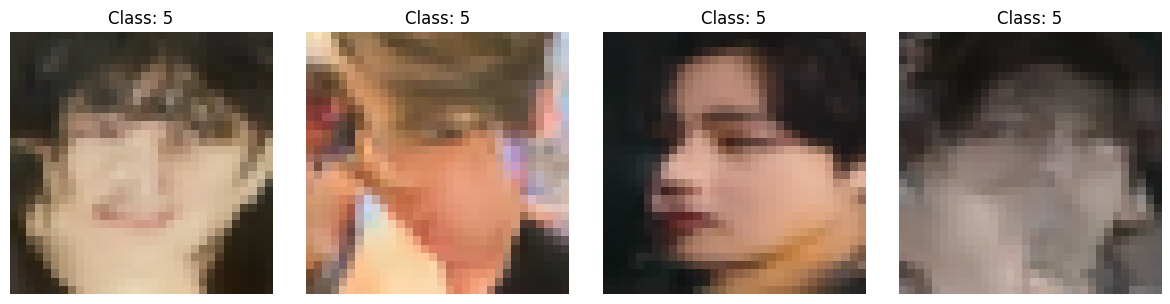

Epoch 43/100: 100%|██████████| 81/81 [00:09<00:00,  8.88it/s, loss=0.0244]


Epoch 232 完成，平均 Loss: 0.0229
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


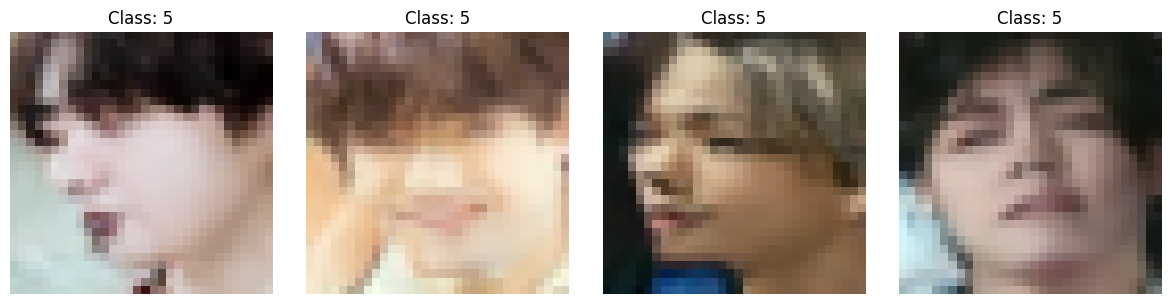

Epoch 44/100: 100%|██████████| 81/81 [00:09<00:00,  8.86it/s, loss=0.0155]


Epoch 233 完成，平均 Loss: 0.0230
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


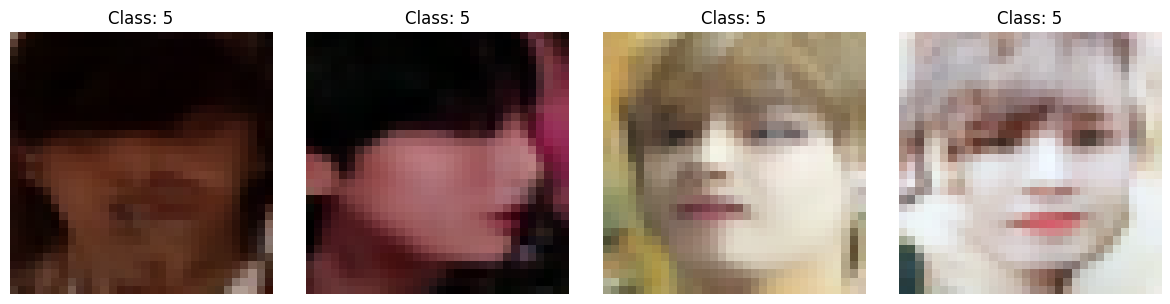

Epoch 45/100: 100%|██████████| 81/81 [00:09<00:00,  8.83it/s, loss=0.0306]


Epoch 234 完成，平均 Loss: 0.0243
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


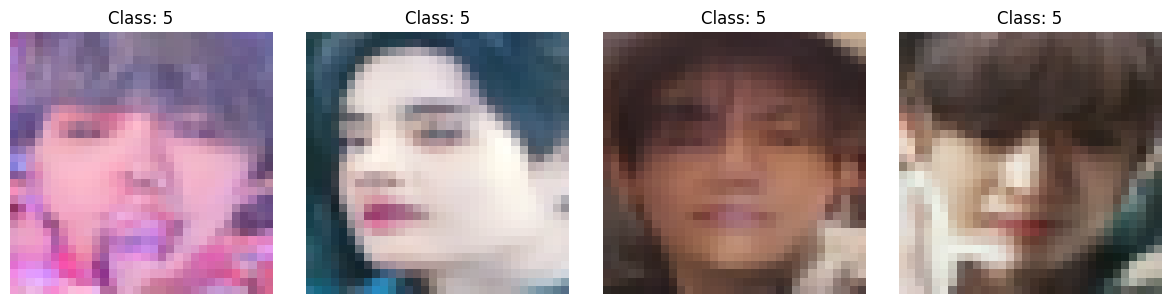

Epoch 46/100: 100%|██████████| 81/81 [00:09<00:00,  8.84it/s, loss=0.0246]


Epoch 235 完成，平均 Loss: 0.0234
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


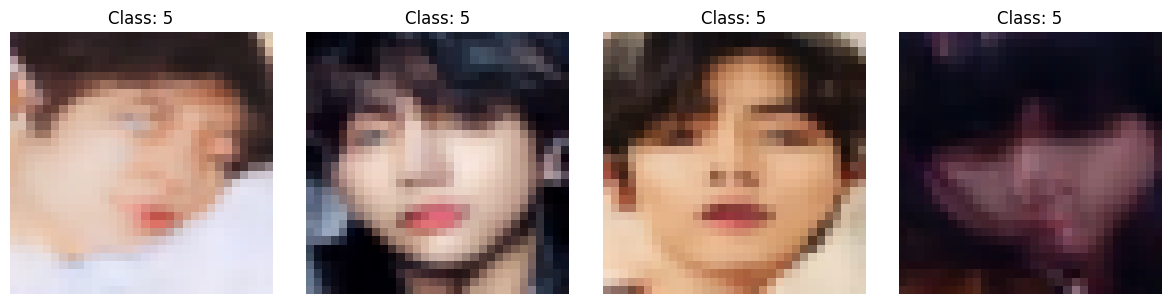

Epoch 47/100: 100%|██████████| 81/81 [00:09<00:00,  8.74it/s, loss=0.0155]


Epoch 236 完成，平均 Loss: 0.0237
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


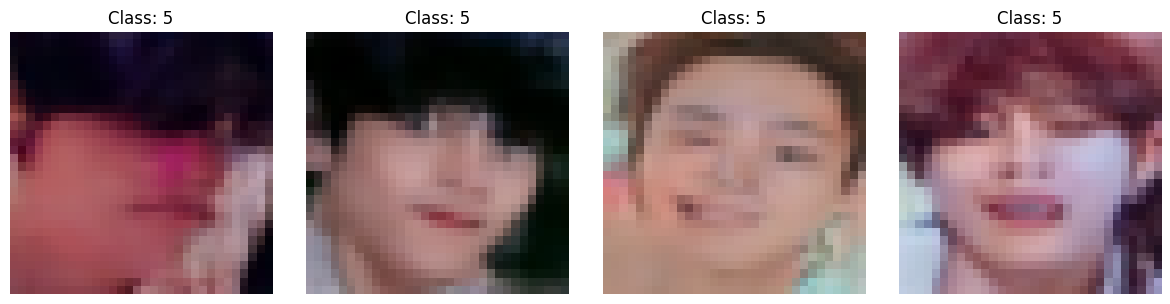

Epoch 48/100: 100%|██████████| 81/81 [00:09<00:00,  8.75it/s, loss=0.0214]


Epoch 237 完成，平均 Loss: 0.0227
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


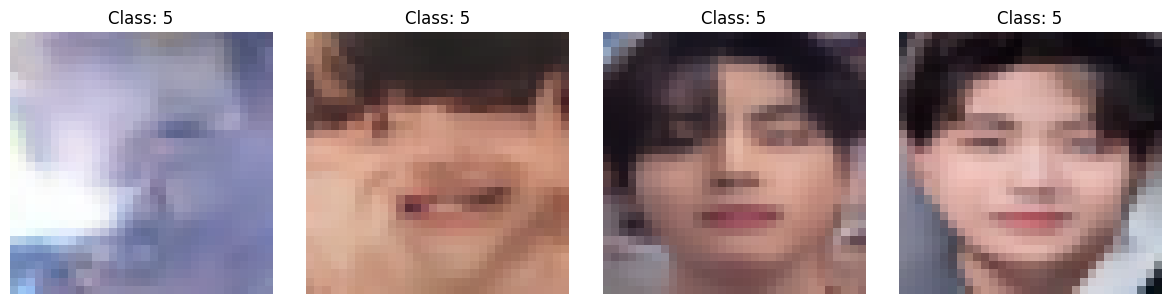

Epoch 49/100: 100%|██████████| 81/81 [00:09<00:00,  8.76it/s, loss=0.0223]


Epoch 238 完成，平均 Loss: 0.0236
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


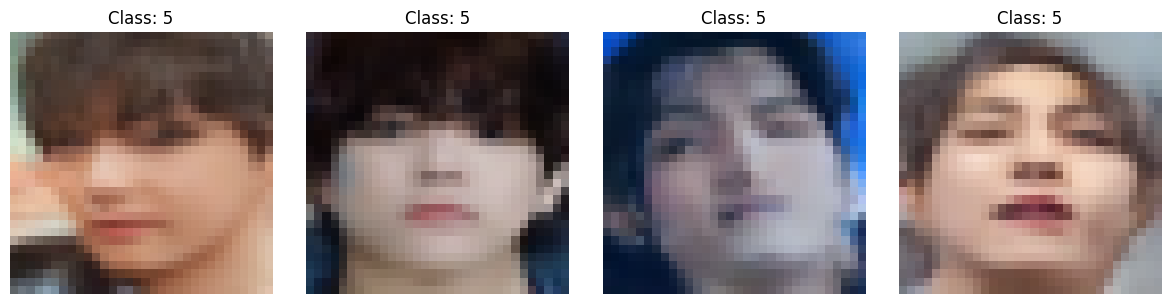

Epoch 50/100: 100%|██████████| 81/81 [00:09<00:00,  8.71it/s, loss=0.0277]


Epoch 239 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


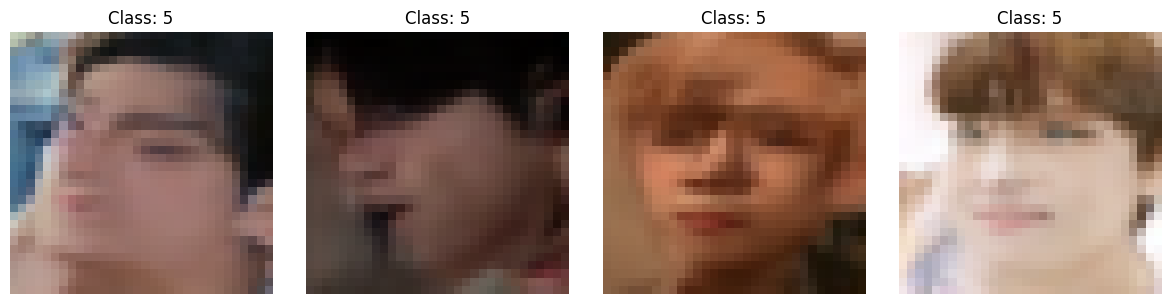

Epoch 51/100: 100%|██████████| 81/81 [00:09<00:00,  8.83it/s, loss=0.0259]


Epoch 240 完成，平均 Loss: 0.0230
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


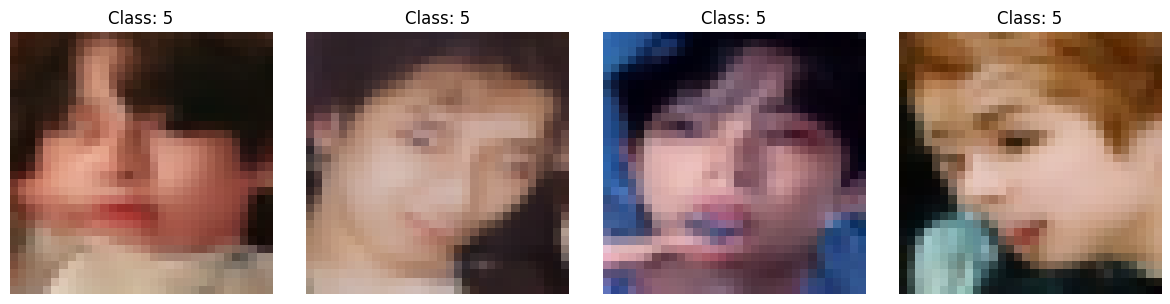

Epoch 52/100: 100%|██████████| 81/81 [00:09<00:00,  8.73it/s, loss=0.0243]


Epoch 241 完成，平均 Loss: 0.0239
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


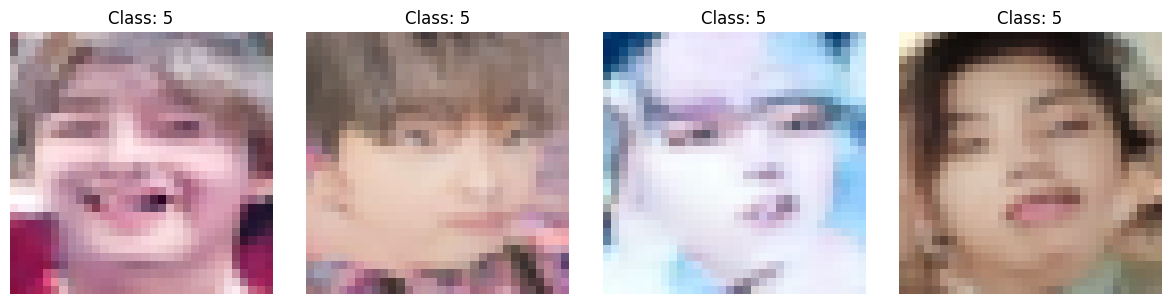

Epoch 53/100: 100%|██████████| 81/81 [00:09<00:00,  8.72it/s, loss=0.0203]


Epoch 242 完成，平均 Loss: 0.0227
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


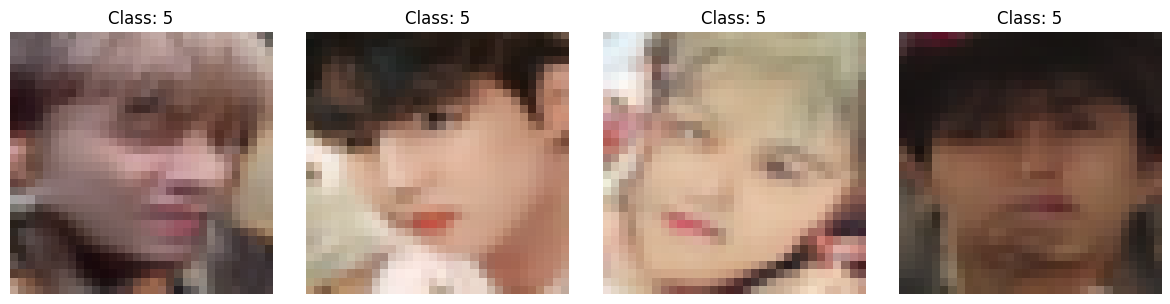

Epoch 54/100: 100%|██████████| 81/81 [00:09<00:00,  8.78it/s, loss=0.0155]


Epoch 243 完成，平均 Loss: 0.0231
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


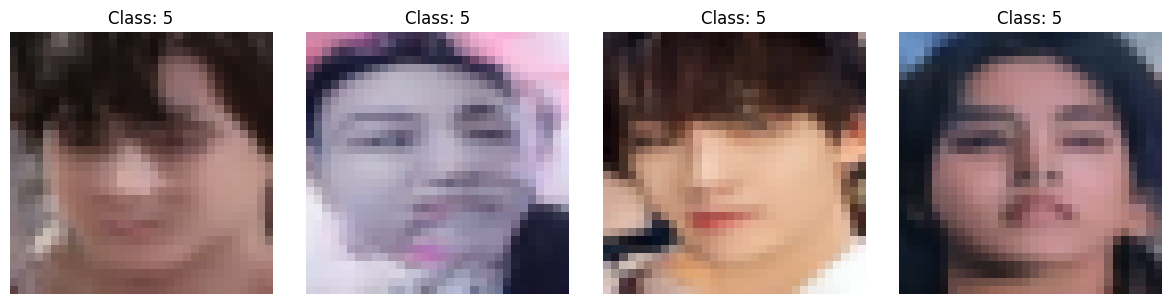

Epoch 55/100: 100%|██████████| 81/81 [00:09<00:00,  8.68it/s, loss=0.0147]


Epoch 244 完成，平均 Loss: 0.0222
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


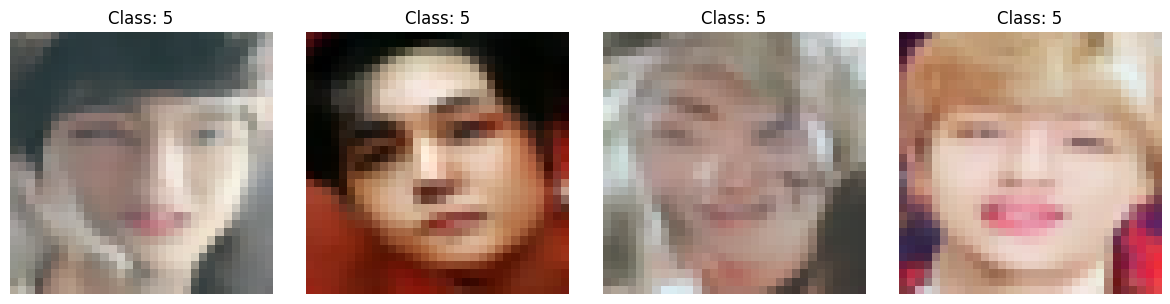

Epoch 56/100: 100%|██████████| 81/81 [00:09<00:00,  8.75it/s, loss=0.0235]


Epoch 245 完成，平均 Loss: 0.0239
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


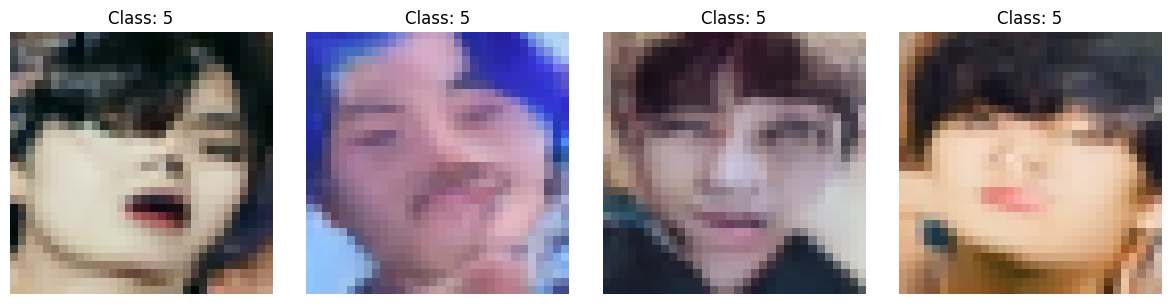

Epoch 57/100: 100%|██████████| 81/81 [00:09<00:00,  8.74it/s, loss=0.0247]


Epoch 246 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


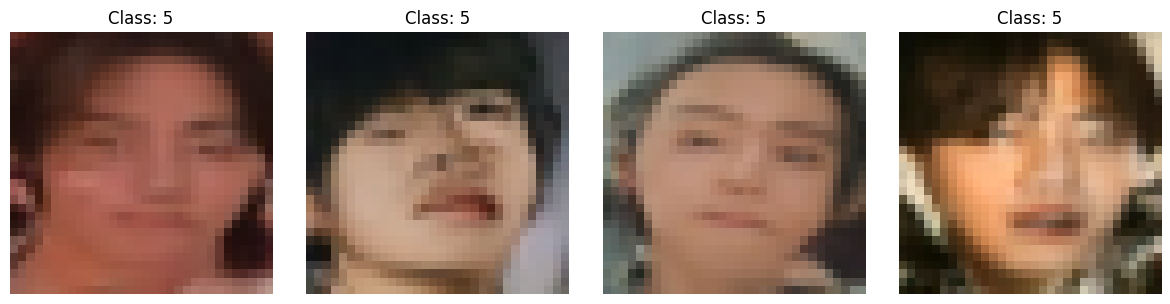

Epoch 58/100: 100%|██████████| 81/81 [00:09<00:00,  8.81it/s, loss=0.0163]


Epoch 247 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


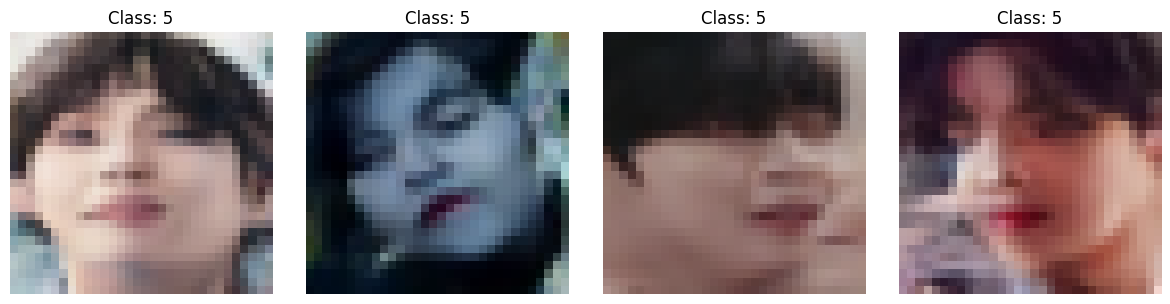

Epoch 59/100: 100%|██████████| 81/81 [00:09<00:00,  8.80it/s, loss=0.0143]


Epoch 248 完成，平均 Loss: 0.0235
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


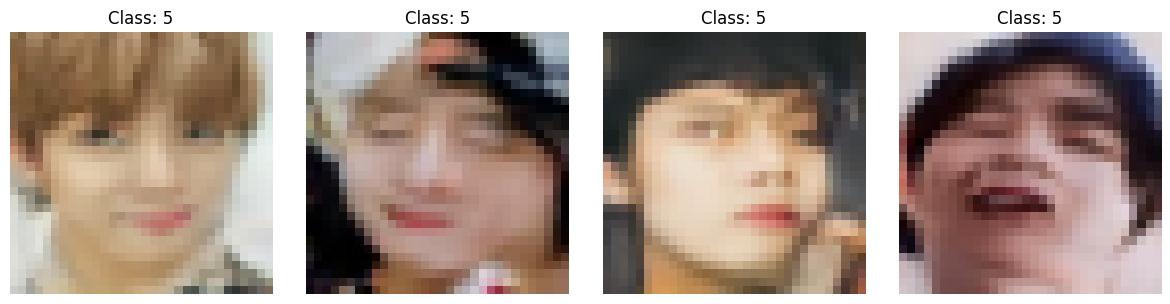

Epoch 60/100: 100%|██████████| 81/81 [00:09<00:00,  8.86it/s, loss=0.0193]


Epoch 249 完成，平均 Loss: 0.0227
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


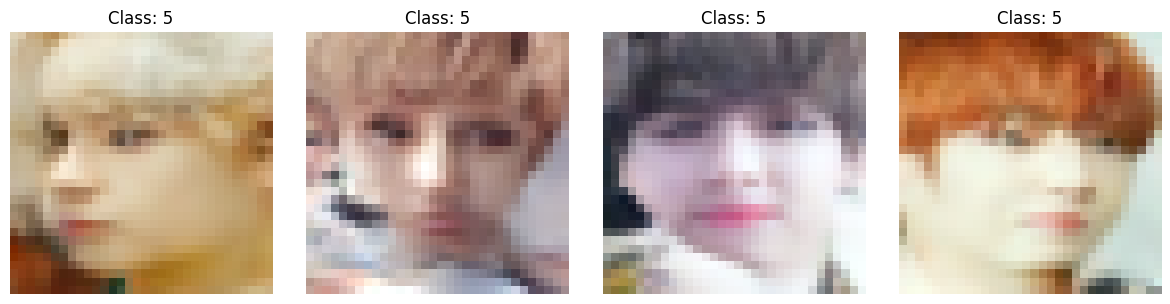

Epoch 61/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.0291]


Epoch 250 完成，平均 Loss: 0.0245
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


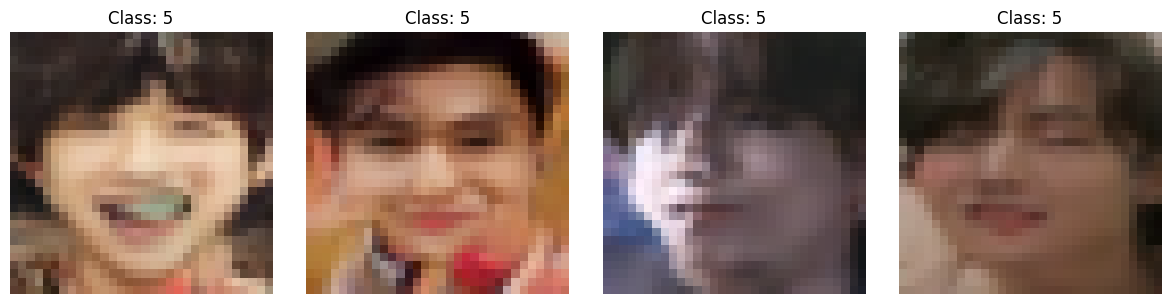

Epoch 62/100: 100%|██████████| 81/81 [00:09<00:00,  8.82it/s, loss=0.0164]


Epoch 251 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


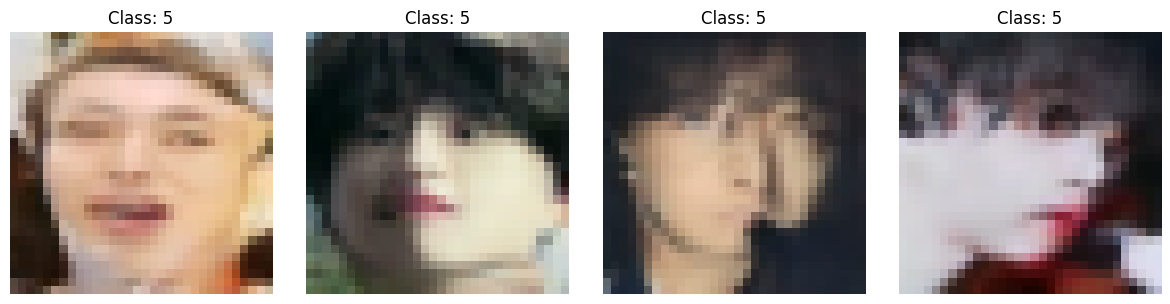

Epoch 63/100: 100%|██████████| 81/81 [00:09<00:00,  8.84it/s, loss=0.0165]


Epoch 252 完成，平均 Loss: 0.0238
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


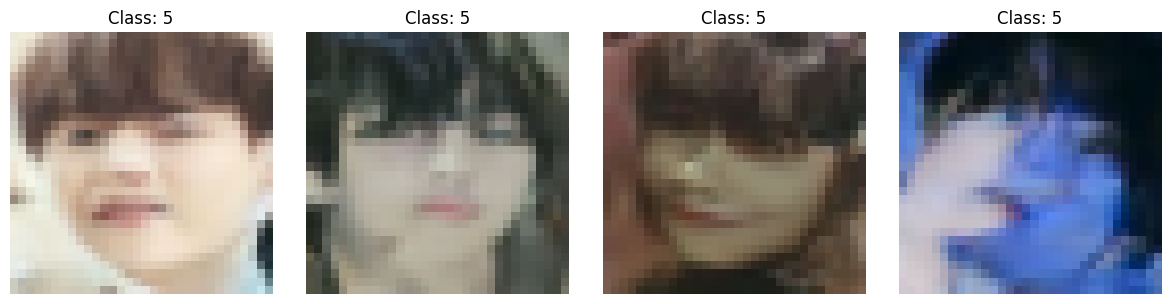

Epoch 64/100: 100%|██████████| 81/81 [00:09<00:00,  8.82it/s, loss=0.0291]


Epoch 253 完成，平均 Loss: 0.0231
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


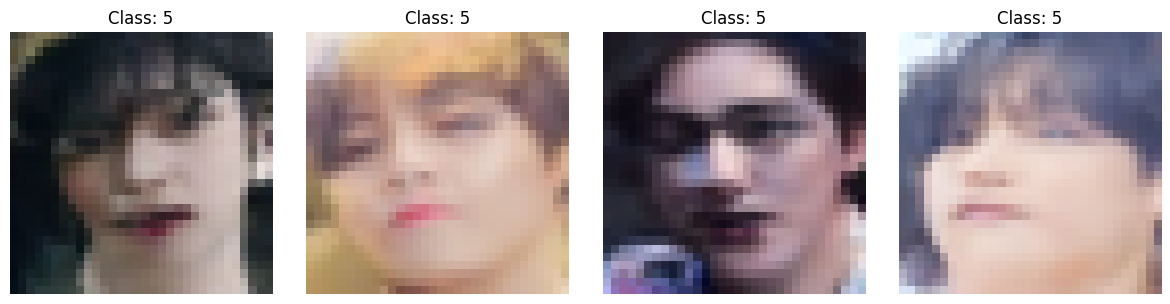

Epoch 65/100: 100%|██████████| 81/81 [00:09<00:00,  8.86it/s, loss=0.0168]


Epoch 254 完成，平均 Loss: 0.0225
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


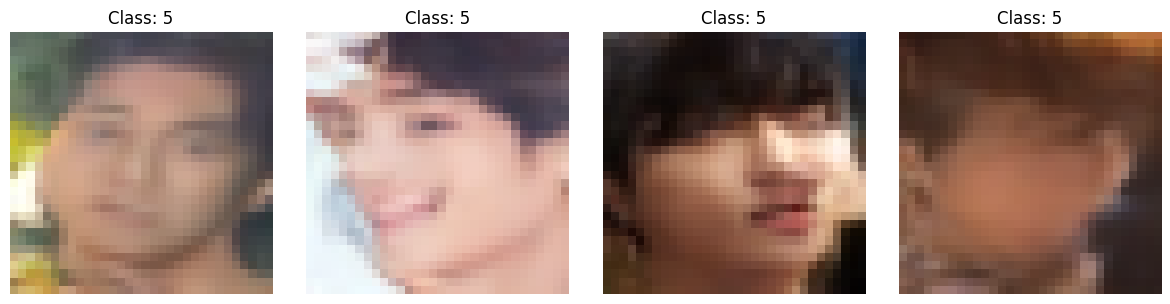

Epoch 66/100: 100%|██████████| 81/81 [00:09<00:00,  8.87it/s, loss=0.0173]


Epoch 255 完成，平均 Loss: 0.0229
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


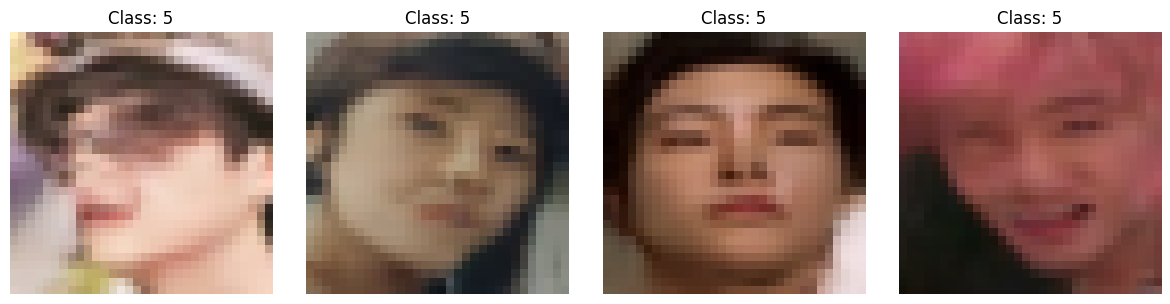

Epoch 67/100: 100%|██████████| 81/81 [00:09<00:00,  8.84it/s, loss=0.0162]


Epoch 256 完成，平均 Loss: 0.0230
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


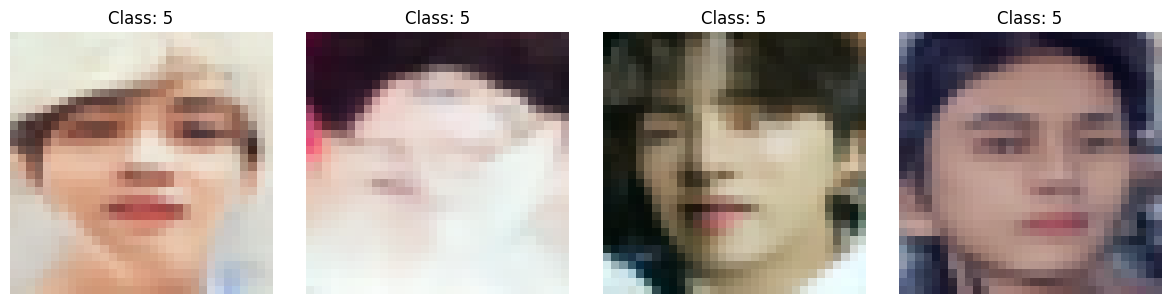

Epoch 68/100: 100%|██████████| 81/81 [00:09<00:00,  8.88it/s, loss=0.0182]


Epoch 257 完成，平均 Loss: 0.0227
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


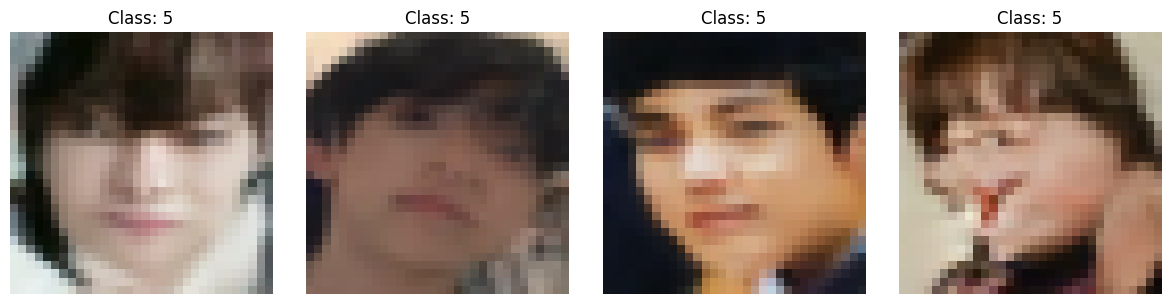

Epoch 69/100: 100%|██████████| 81/81 [00:09<00:00,  8.81it/s, loss=0.0216]


Epoch 258 完成，平均 Loss: 0.0235
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


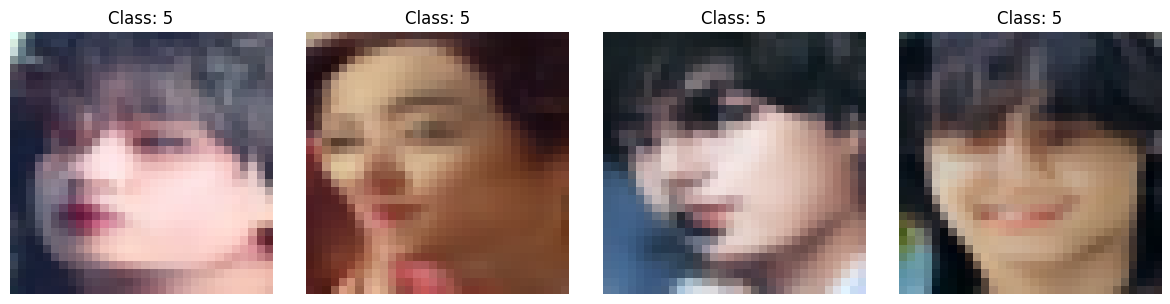

Epoch 70/100: 100%|██████████| 81/81 [00:09<00:00,  8.92it/s, loss=0.0207]


Epoch 259 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


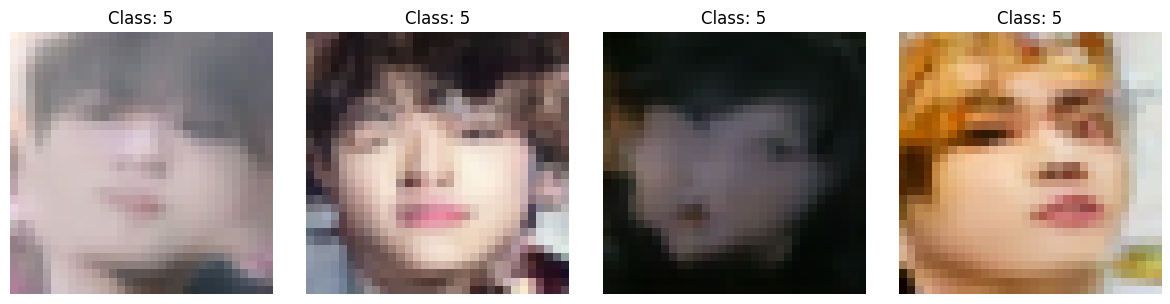

Epoch 71/100: 100%|██████████| 81/81 [00:09<00:00,  8.89it/s, loss=0.019]


Epoch 260 完成，平均 Loss: 0.0235
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


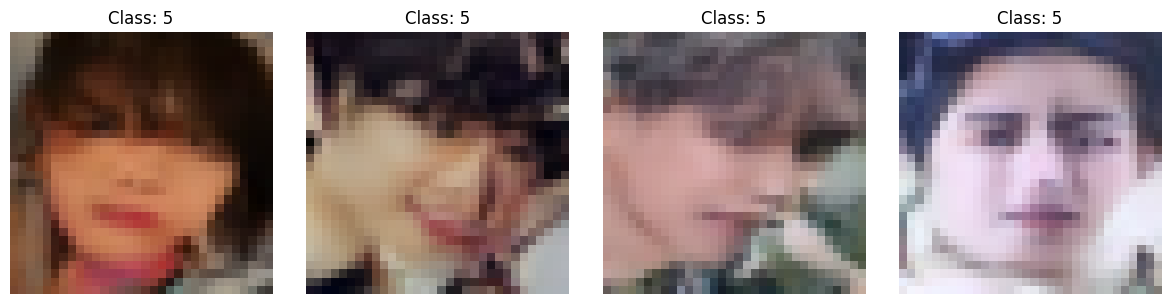

Epoch 72/100: 100%|██████████| 81/81 [00:09<00:00,  8.89it/s, loss=0.0226]


Epoch 261 完成，平均 Loss: 0.0228
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


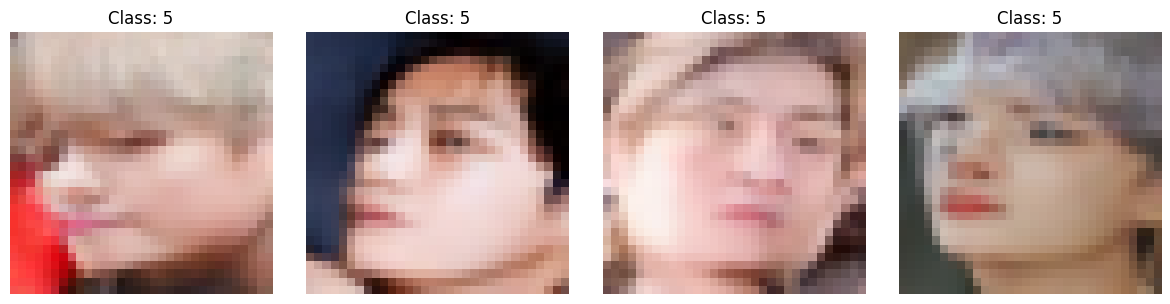

Epoch 73/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.0139]


Epoch 262 完成，平均 Loss: 0.0229
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


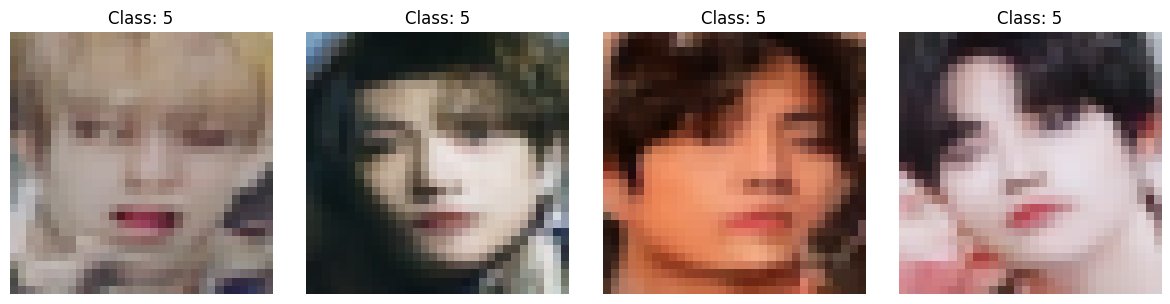

Epoch 74/100: 100%|██████████| 81/81 [00:09<00:00,  8.88it/s, loss=0.0263]


Epoch 263 完成，平均 Loss: 0.0231
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


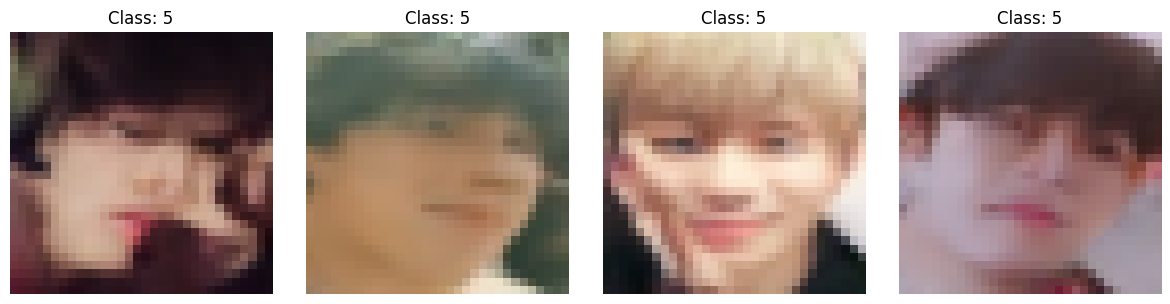

Epoch 75/100: 100%|██████████| 81/81 [00:09<00:00,  8.89it/s, loss=0.0195]


Epoch 264 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


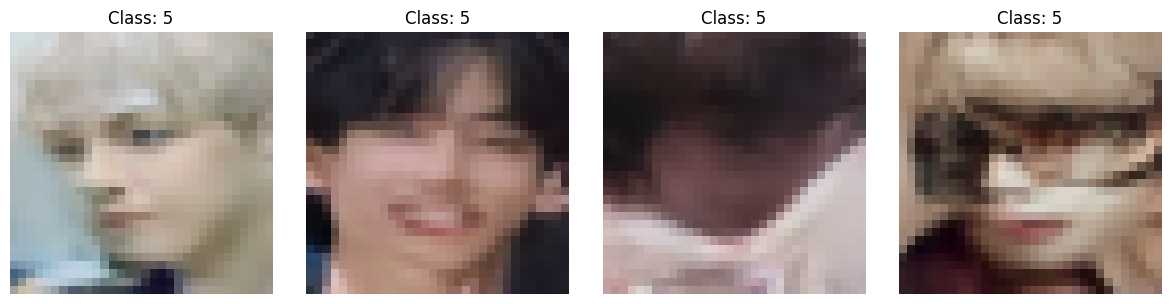

Epoch 76/100: 100%|██████████| 81/81 [00:09<00:00,  8.88it/s, loss=0.0253]


Epoch 265 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


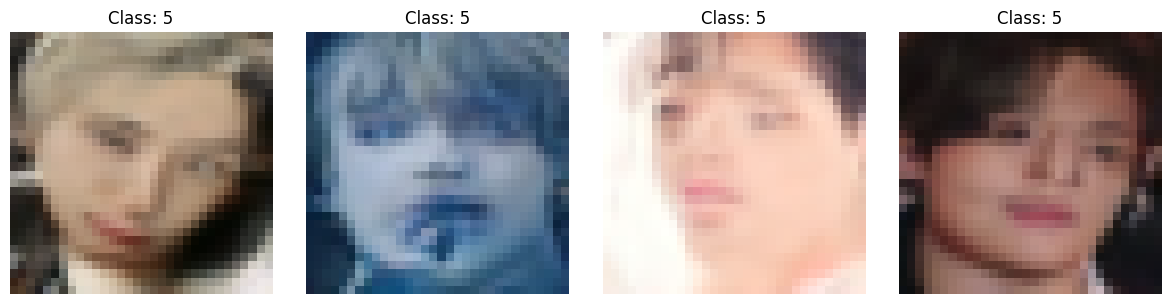

Epoch 77/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.0232]


Epoch 266 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


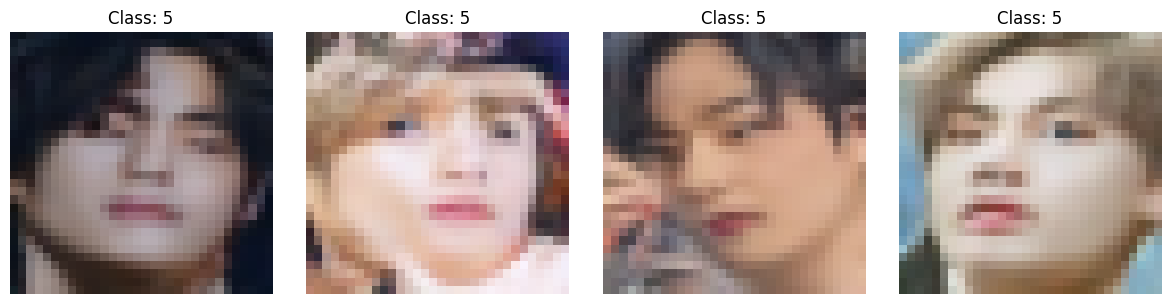

Epoch 78/100: 100%|██████████| 81/81 [00:09<00:00,  8.80it/s, loss=0.0266]


Epoch 267 完成，平均 Loss: 0.0226
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


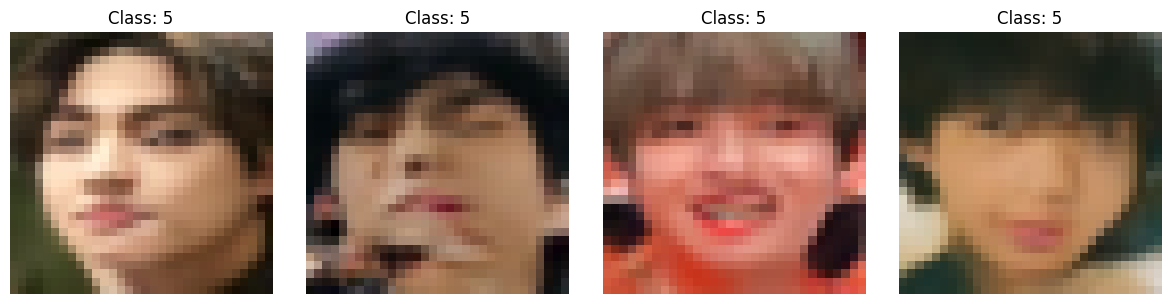

Epoch 79/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.027]


Epoch 268 完成，平均 Loss: 0.0225
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


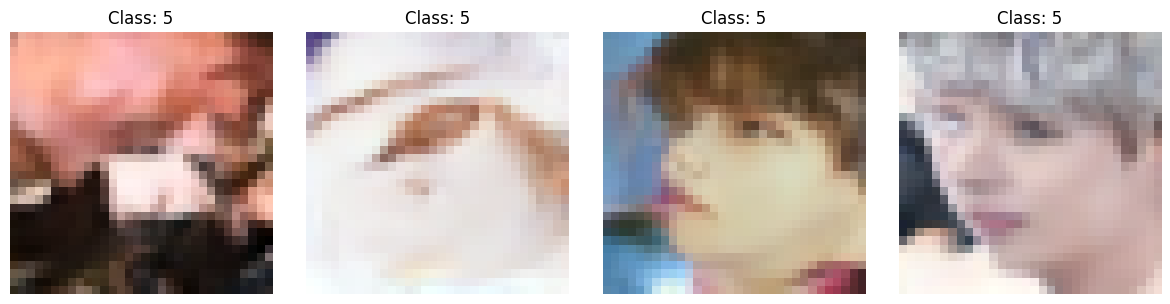

Epoch 80/100: 100%|██████████| 81/81 [00:09<00:00,  8.84it/s, loss=0.0205]


Epoch 269 完成，平均 Loss: 0.0238
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


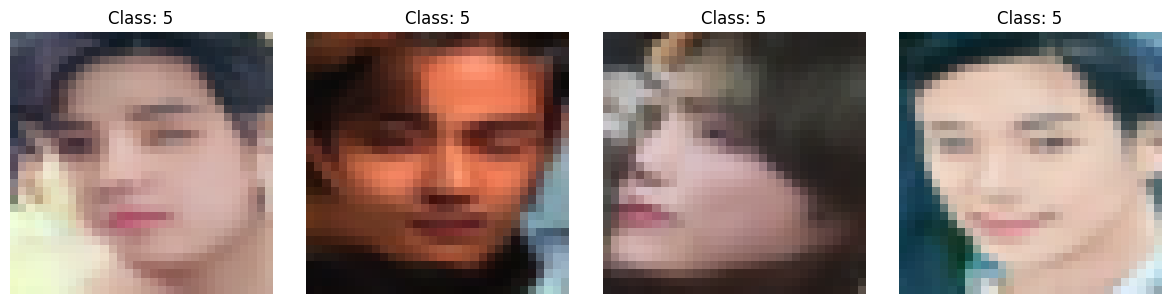

Epoch 81/100: 100%|██████████| 81/81 [00:09<00:00,  8.14it/s, loss=0.0249]


Epoch 270 完成，平均 Loss: 0.0239
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


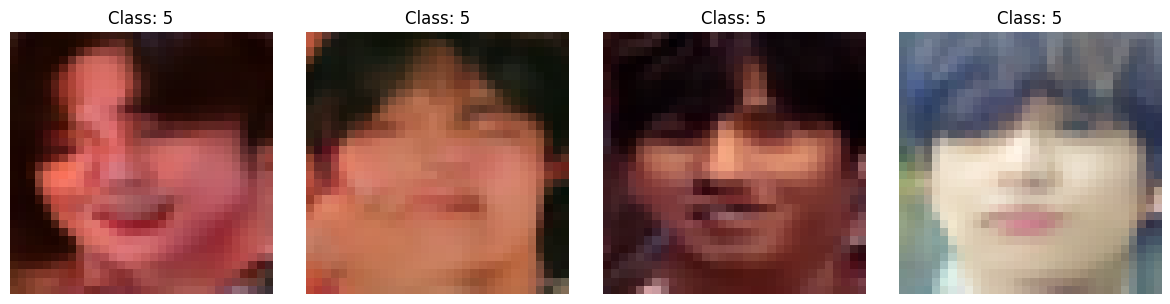

Epoch 82/100: 100%|██████████| 81/81 [00:09<00:00,  8.85it/s, loss=0.0218]


Epoch 271 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


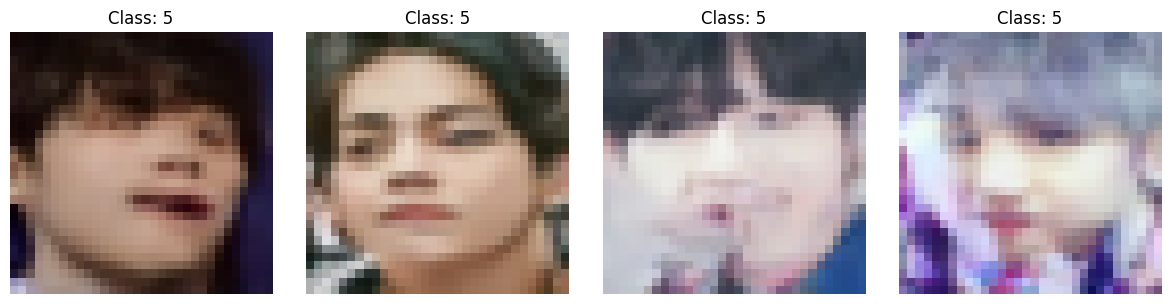

Epoch 83/100: 100%|██████████| 81/81 [00:09<00:00,  8.83it/s, loss=0.0279]


Epoch 272 完成，平均 Loss: 0.0230
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


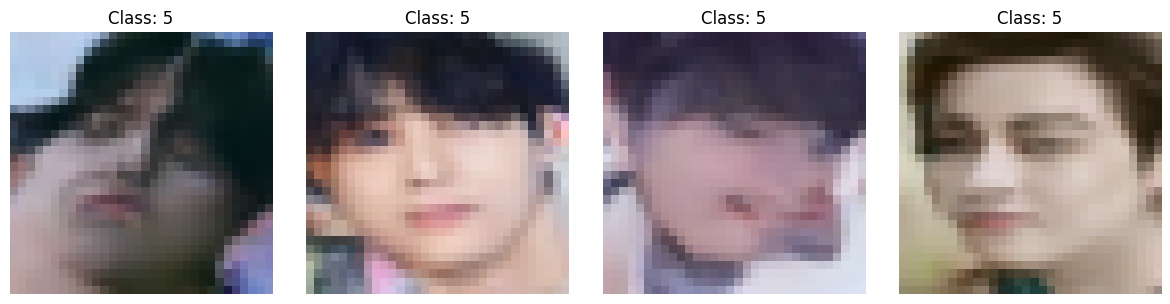

Epoch 84/100: 100%|██████████| 81/81 [00:09<00:00,  8.86it/s, loss=0.0206]


Epoch 273 完成，平均 Loss: 0.0225
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


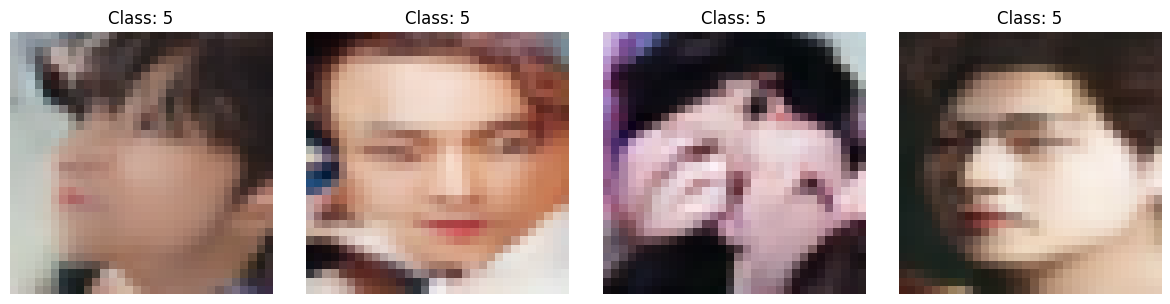

Epoch 85/100: 100%|██████████| 81/81 [00:09<00:00,  8.86it/s, loss=0.0225]


Epoch 274 完成，平均 Loss: 0.0230
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


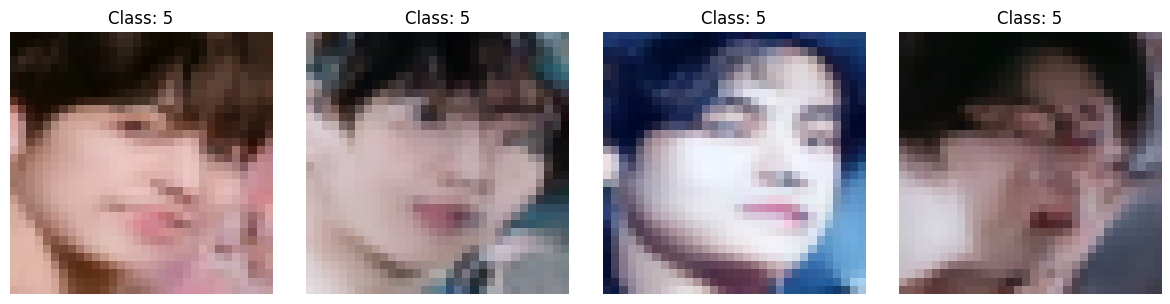

Epoch 86/100: 100%|██████████| 81/81 [00:09<00:00,  8.87it/s, loss=0.0203]


Epoch 275 完成，平均 Loss: 0.0234
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


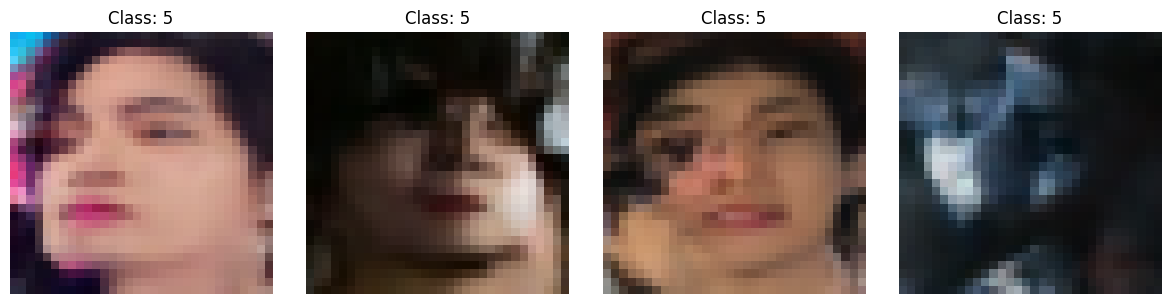

Epoch 87/100: 100%|██████████| 81/81 [00:09<00:00,  8.75it/s, loss=0.015]


Epoch 276 完成，平均 Loss: 0.0233
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


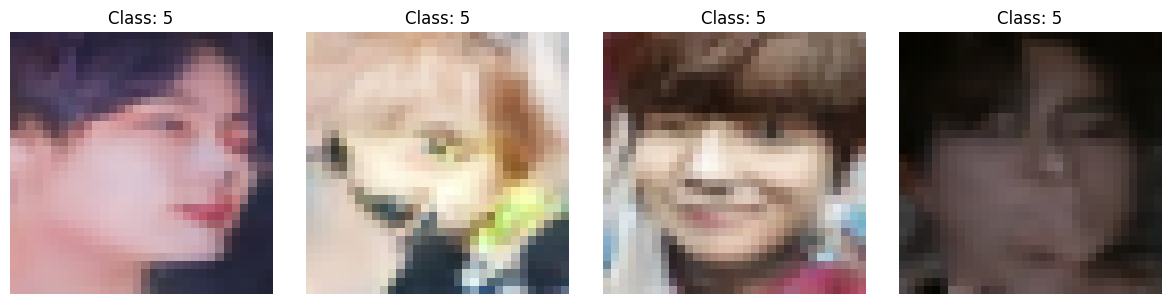

Epoch 88/100: 100%|██████████| 81/81 [00:09<00:00,  8.73it/s, loss=0.0189]


Epoch 277 完成，平均 Loss: 0.0221
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


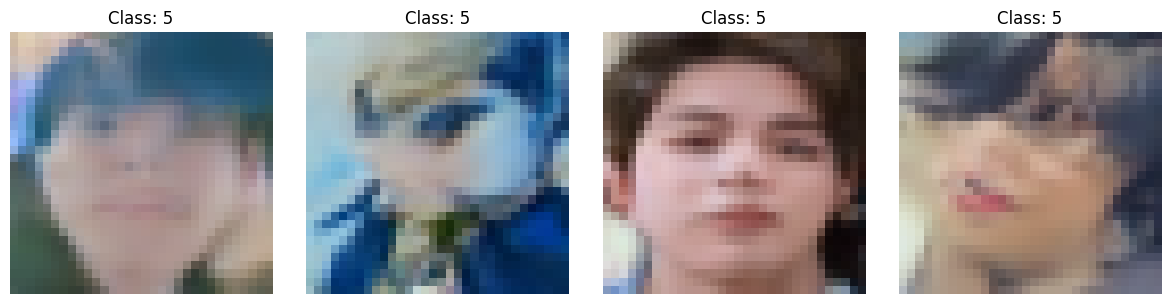

Epoch 89/100: 100%|██████████| 81/81 [00:09<00:00,  8.73it/s, loss=0.02]


Epoch 278 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


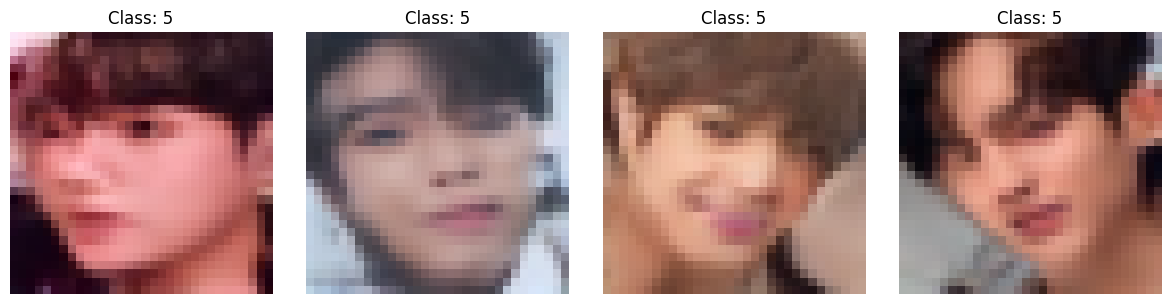

Epoch 90/100: 100%|██████████| 81/81 [00:09<00:00,  8.74it/s, loss=0.0174]


Epoch 279 完成，平均 Loss: 0.0235
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


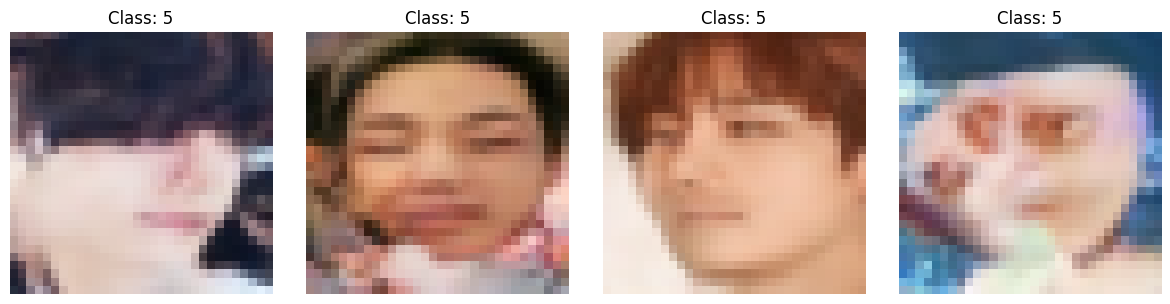

Epoch 91/100: 100%|██████████| 81/81 [00:09<00:00,  8.74it/s, loss=0.0248]


Epoch 280 完成，平均 Loss: 0.0238
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


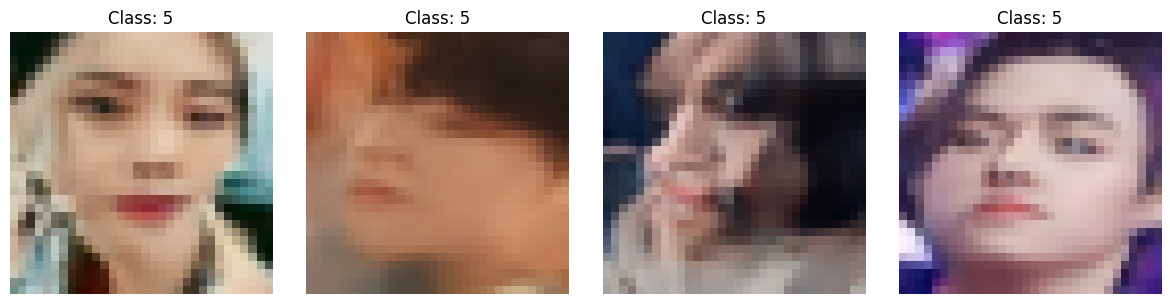

Epoch 92/100: 100%|██████████| 81/81 [00:09<00:00,  8.69it/s, loss=0.0338]


Epoch 281 完成，平均 Loss: 0.0234
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


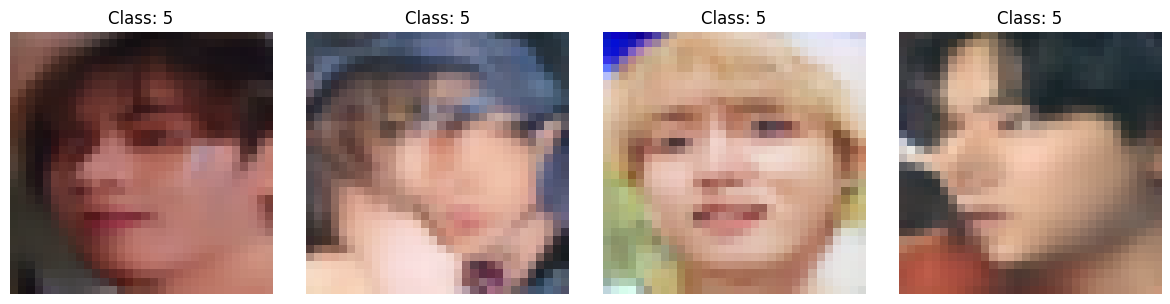

Epoch 93/100: 100%|██████████| 81/81 [00:09<00:00,  8.72it/s, loss=0.0177]


Epoch 282 完成，平均 Loss: 0.0223
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


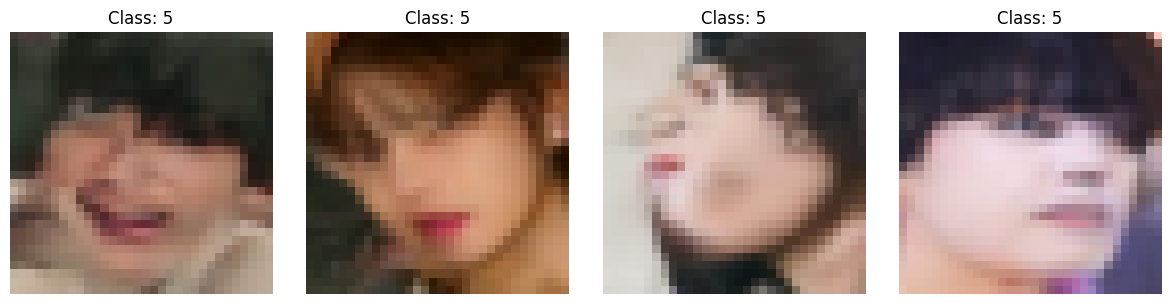

Epoch 94/100: 100%|██████████| 81/81 [00:09<00:00,  8.68it/s, loss=0.0282]


Epoch 283 完成，平均 Loss: 0.0224
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


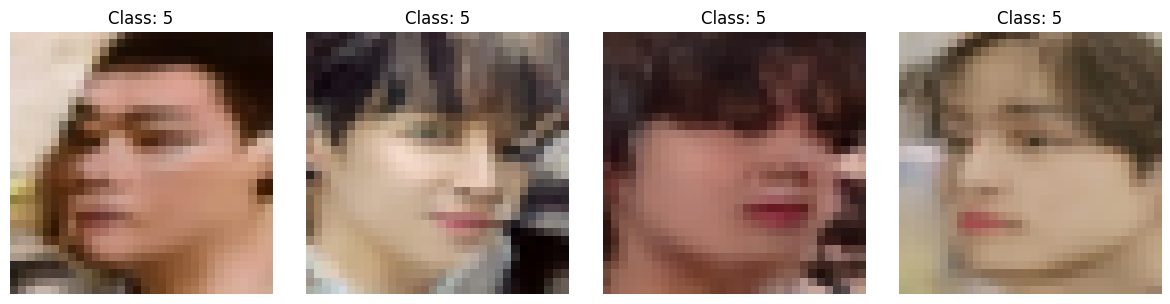

Epoch 95/100: 100%|██████████| 81/81 [00:09<00:00,  8.66it/s, loss=0.0264]


Epoch 284 完成，平均 Loss: 0.0230
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


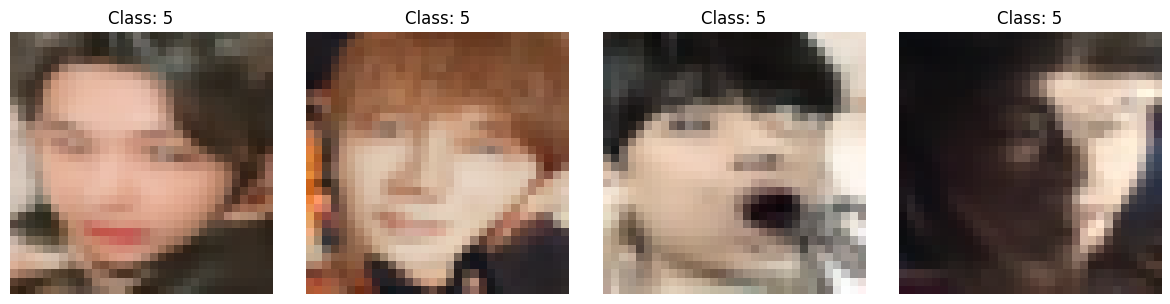

Epoch 96/100: 100%|██████████| 81/81 [00:09<00:00,  8.71it/s, loss=0.0215]


Epoch 285 完成，平均 Loss: 0.0223
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


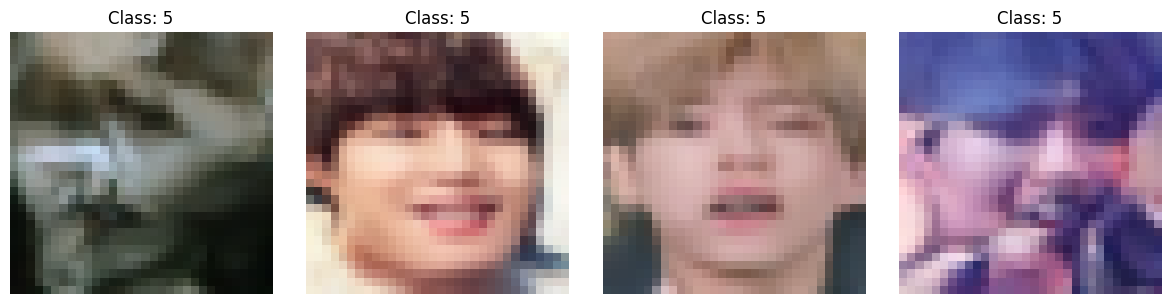

Epoch 97/100: 100%|██████████| 81/81 [00:09<00:00,  8.70it/s, loss=0.0364]


Epoch 286 完成，平均 Loss: 0.0234
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


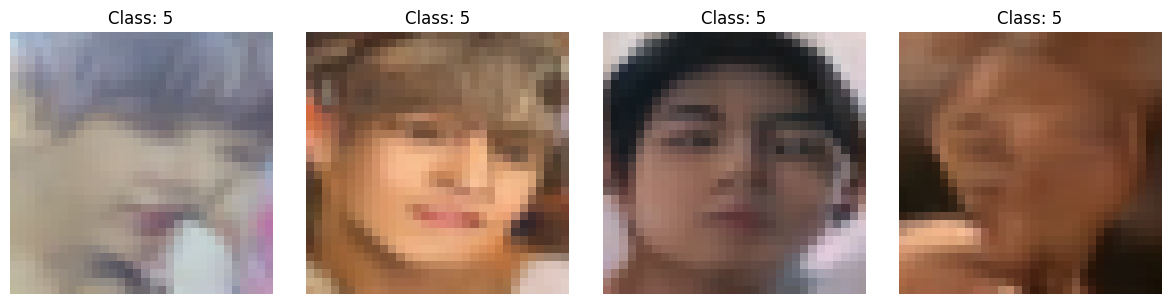

Epoch 98/100: 100%|██████████| 81/81 [00:09<00:00,  8.73it/s, loss=0.0217]


Epoch 287 完成，平均 Loss: 0.0231
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


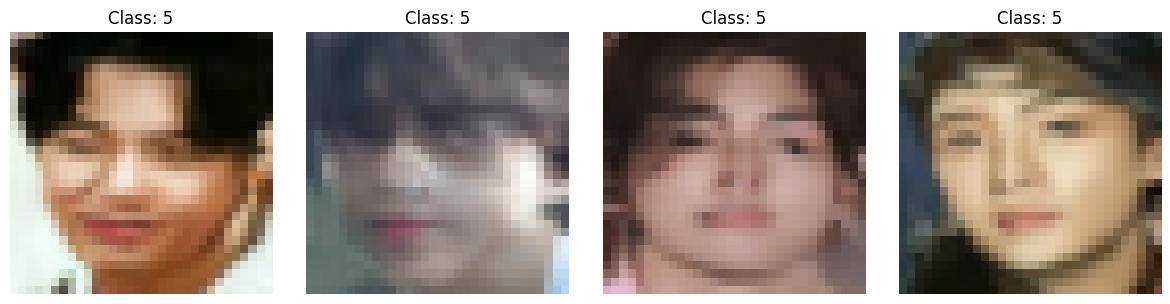

Epoch 99/100: 100%|██████████| 81/81 [00:09<00:00,  8.82it/s, loss=0.0159]


Epoch 288 完成，平均 Loss: 0.0229
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


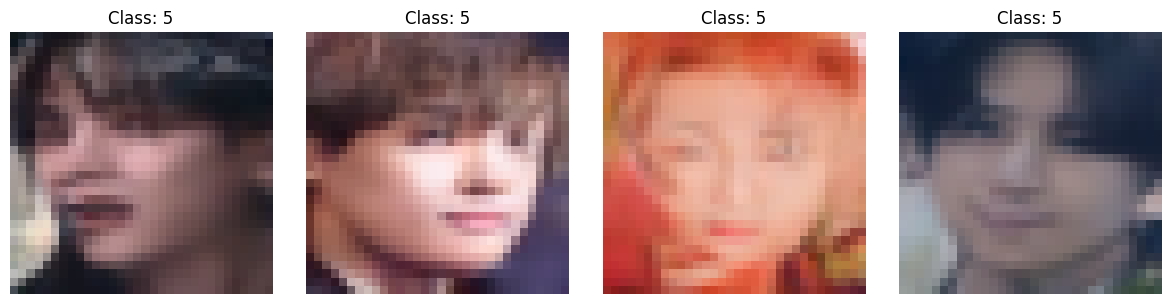

Epoch 100/100: 100%|██████████| 81/81 [00:09<00:00,  8.87it/s, loss=0.0139]


Epoch 289 完成，平均 Loss: 0.0232
開始生成類別 5 的圖片...
生成完成！輸出圖片形狀: torch.Size([4, 3, 32, 32])
正在處理並顯示圖片...
顯示結果 (因模型未訓練，顯示為隨機噪聲是正常的):


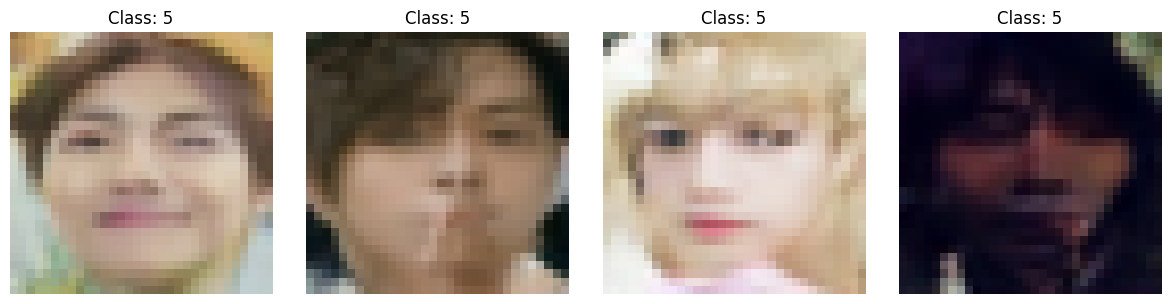

訓練結束！


In [12]:
num_epochs = 100

for epoch in range(num_epochs):
    model.train() # 切換到訓練模式
    epoch_loss = 0.0

    if epochs_completed > 200 and param_group['lr'] != 1e-6:
        print(f"💡 觸發 Learning Rate 衰減：從 1e-4 降為 1e-5 on {epochs_completed + 1}")
        for param_group in optimizer.param_groups:
            param_group['lr'] = 1e-6

    # 加上進度條方便看
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for step, batch in enumerate(progress_bar):
        clean_images, labels = batch
        clean_images = clean_images.to(device)
        labels = labels.to(device)

        # A. 採樣隨機噪音
        noise = torch.randn_like(clean_images)
        bs = clean_images.shape[0]

        # B. 採樣隨機時間步 (Timesteps)
        timesteps = torch.randint(
            0, scheduler.config.num_train_timesteps, (bs,), device=device
        ).long()

        # C. 加噪 (Forward Process)
        noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

        # D. 模型預測 (Forward Pass)
        # 記得傳入 class_labels
        noise_pred = model(
            noisy_images,
            timesteps,
            class_labels=labels
        ).sample

        # E. 計算 Loss
        loss = F.mse_loss(noise_pred, noise)

        # F. 反向傳播與參數更新 (Backward & Step)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 更新進度條顯示
        epoch_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = epoch_loss / len(train_dataloader)

    print(f"Epoch {epochs_completed + 1} 完成，平均 Loss: {avg_loss:.4f}")
    epochs_completed += 1

    model.save_pretrained(output_dir)

    scheduler.save_pretrained(output_dir)
    inference_demo(model)

print("訓練結束！")

In [ ]:
# output_dir = "/content/drive/Shareddrives/Computer Vision/models"
# model.save_pretrained(output_dir)

# scheduler.save_pretrained(output_dir)

